# Automotive Price Prediction & Vehicle Classification
## End-to-End Data Science Pipeline

---

| | |
|---|---|
| **Course** | Data Science and Analytics (MCT-341L) |
| **Instructor** | Dr. Muhammad Ahsan Naeem |
| **Department** | Mechatronics and Control Engineering, UET Lahore |
| **Members** | 2023-MC-53 · 2023-MC-65 |
| **Dataset** | Car Features and MSRP (Kaggle — CooperUnion, CC0) |
| **Regression Target** | MSRP — Manufacturer's Suggested Retail Price (USD) |
| **Classification Target** | Vehicle Size — Compact / Midsize / Large |
| **Phases** | 9 |
| **Submission Date** | June 2026 |

---

## AI Assistance Disclosure

This project was developed with the assistance of Claude (Anthropic) as an 
AI learning tool. The AI was used for:

- **Syntax guidance** — correcting code errors and explaining unfamiliar functions
- **Concept explanation** — understanding new libraries (Seaborn, Scikit-learn) 
  and statistical concepts (skewness, kurtosis, regularisation)
- **Markdown generation** — producing formatted observation and interpretation cells
- **Debugging** — identifying and resolving runtime errors

All **analytical decisions**, **domain justifications**, **modelling choices**, 
and **interpretations** were made by the authors after genuine understanding. 
Every line of code was written, reviewed, and understood by both group members 
independently.

This disclosure is made in accordance with the AI-Use Policy stated in the 
project specification (MCT-341L).

---

# Phase 1: Dataset Acquisition & Initial Exploration

## 1.1 Load and Inspect

This cell loads the dataset from the local CSV file and displays its structure 
including shape, column names, data types, memory usage, and missing value counts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv("data.csv")

# Quick sanity check
print(df.head(10))
print(df.info())
print(df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(df.columns)

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   
5  BMW    1 Series  2012  premium unleaded (required)      230.0   
6  BMW    1 Series  2012  premium unleaded (required)      300.0   
7  BMW    1 Series  2012  premium unleaded (required)      300.0   
8  BMW    1 Series  2012  premium unleaded (required)      230.0   
9  BMW    1 Series  2013  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0    

## Observations from Initial Inspection

The dataset contains **11,914 rows and 16 columns**, covering car specifications 
and pricing data from multiple manufacturers. Out of 16 columns, **8 are numerical** 
(Year, Engine HP, Engine Cylinders, Number of Doors, highway MPG, city mpg, 
Popularity, MSRP) and **8 are categorical** (Make, Model, Engine Fuel Type, 
Transmission Type, Driven_Wheels, Market Category, Vehicle Size, Vehicle Style).

Missing values are present in 5 columns: **Market Category has the most with 
3,742 missing values (31.4%)**, followed by Engine HP (69), Engine Cylinders (30), 
Number of Doors (6), and Engine Fuel Type (3). These will require careful 
imputation strategies.

The dataset occupies approximately **6.08 MB** in memory. The target variables 
identified are **MSRP** (continuous — for regression) and **Vehicle Size** 
(categorical: Compact/Midsize/Large — for classification).

## 1.2 Data Card

| Field | Details |
|---|---|
| **Source URL** | https://www.kaggle.com/datasets/CooperUnion/cardataset |
| **Licence** | CC0 — Public Domain |
| **Collection Method** | Scraped from Edmunds and Twitter; data represents manufacturer-reported specifications |
| **Collection Period** | Model years 1990 to 2017 |
| **Known Limitations** | MSRP reflects original manufacturer price — does not account for depreciation, dealer markups, or regional pricing differences |
| **Sampling Biases** | Dataset is heavily skewed toward US market vehicles and popular brands; rare or regional manufacturers are underrepresented. Older models (pre-2000) have fewer entries than recent years |


## 1.3 Statistical Snapshot

This cell runs `df.describe(include="all")` to generate a full statistical 
summary of all 16 columns — both numerical and categorical — to identify 
skewness, implausible values, and data quality issues before modelling.

In [2]:
df.describe(include="all") # statistical summary of every column (numerical + categorical)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
count,11914,11914,11914.000000,11911,11845.00000,11884.000000,11914,11914,11908.000000,8172,11914,11914,11914.000000,11914.000000,11914.000000,1.191400e+04
unique,48,915,NaN,10,NaN,NaN,5,4,NaN,71,3,16,NaN,NaN,NaN,NaN
top,Chevrolet,Silverado 1500,NaN,regular unleaded,NaN,NaN,AUTOMATIC,front wheel drive,NaN,Crossover,Compact,Sedan,NaN,NaN,NaN,NaN
freq,1123,156,NaN,7172,NaN,NaN,8266,4787,NaN,1110,4764,3048,NaN,NaN,NaN,NaN
mean,NaN,NaN,2010.384338,NaN,249.38607,5.628829,NaN,NaN,3.436093,NaN,NaN,NaN,26.637485,19.733255,1554.911197,4.059474e+04
std,NaN,NaN,7.579740,NaN,109.19187,1.780559,NaN,NaN,0.881315,NaN,NaN,NaN,8.863001,8.987798,1441.855347,6.010910e+04
min,NaN,NaN,1990.000000,NaN,55.00000,0.000000,NaN,NaN,2.000000,NaN,NaN,NaN,12.000000,7.000000,2.000000,2.000000e+03
25%,NaN,NaN,2007.000000,NaN,170.00000,4.000000,NaN,NaN,2.000000,NaN,NaN,NaN,22.000000,16.000000,549.000000,2.100000e+04
50%,NaN,NaN,2015.000000,NaN,227.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,26.000000,18.000000,1385.000000,2.999500e+04
75%,NaN,NaN,2016.000000,NaN,300.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,30.000000,22.000000,2009.000000,4.223125e+04


## Observations from Statistical Snapshot

### Mean vs Median Check (>20% difference flags skewness)

| Column | Mean | Median | Difference % | Flag |
|---|---|---|---|---|
| MSRP | 40,594 | 29,995 | 35.3% | Right-skewed — luxury/exotic cars inflate the mean |
| Engine HP | 249 | 227 | 9.7% |   Acceptable |
| Popularity | 1,554 | 1,385 | 12.2% | Acceptable |
| highway MPG | 26.6 | 26 | 2.3% | Acceptable |
| city mpg | 19.7 | 18 | 9.4% | Acceptable |

### Physically Implausible Values

| Column | Issue | Explanation |
|---|---|---|
| Engine Cylinders | min = **0.0** | No real combustion engine has 0 cylinders — likely electric vehicle recorded incorrectly |
| highway MPG | max = **354** | No conventional car achieves 354 MPG — likely a data entry error |
| city mpg | max = **137** | Implausibly high for a conventional vehicle |
| MSRP | max = **$2,065,902** | Plausible — corresponds to ultra-luxury exotic cars |
| Engine HP | max = **1001** | Plausible — high-performance supercars (Bugatti Chiron) exceed 1000 HP |

### Key Takeaway
MSRP is heavily right-skewed due to exotic cars and will require log transformation 
before regression modelling. Engine Cylinders minimum of 0 and extremely high MPG 
values will be treated as outliers in Phase 3.

## 1.4 Target Variable Definition

### Regression Target — MSRP
- **Type:** Continuous numerical variable
- **Physical Meaning:** MSRP (Manufacturer's Suggested Retail Price) represents 
the price in US Dollars ($) that a manufacturer recommends a dealer must charge for 
a vehicle.
- **Justification:** MSRP is a suitable regression target because it varies 
continuously from $2,000 to $2,065,902 and is directly influenced by engineering 
features such as Engine HP, Engine Cylinders, and fuel efficiency (MPG). 
Predicting MSRP from these features is a meaningful and well-defined 
engineering problem.

### Classification Target — Vehicle Size
- **Type:** Categorical variable with 3 ordered classes
- **Categories:** Compact / Midsize / Large
- **Justification:** Vehicle Size is a natural categorical column already present 
in the dataset — no binning or derivation was required. The three classes 
represent physically meaningful size categories defined by the manufacturer, 
making this a valid and domain-justified classification target.

## 1.5. Class Balance Check

This cell calculates imbalance ratio, necessary for modeling, and plots a bar chart of classification target.
The Imbalance Ratio (IR) measures how lopsided or uneven a dataset is when comparing the majority class to the minority class.

Vehicle Size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64


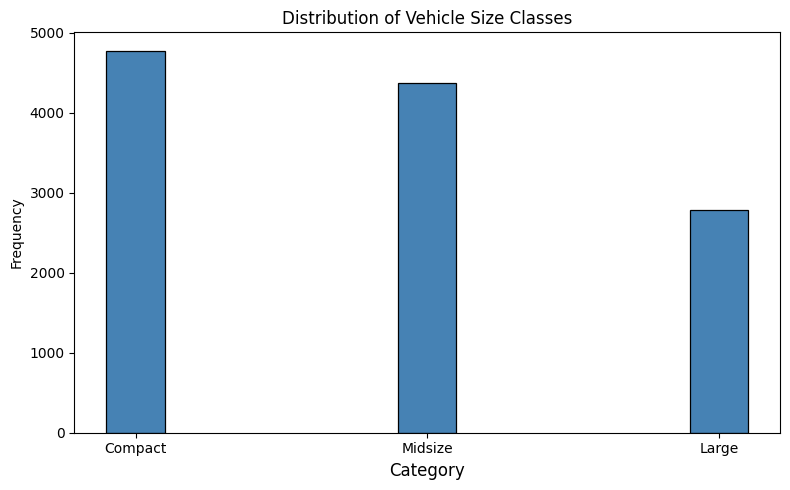

Imbalance ratio: 1.72:1


In [3]:
# Bar chart of classification target
counts = df["Vehicle Size"].value_counts()
print(counts)

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, width=0.2, color='steelblue', edgecolor='black', linewidth=0.9)

plt.title("Distribution of Vehicle Size Classes", fontsize=12)
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Imbalance Ratio
imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

## Class Balance Check

The classification target **Vehicle Size** has the following class distribution:
- **Compact:** 4,764 vehicles (40.0%)
- **Midsize:** 4,028 vehicles (33.8%)
- **Large:** 3,122 vehicles (26.2%)

The imbalance ratio (majority ÷ minority) = **1.72:1**, which is well below the 
5:1 threshold. Therefore, the dataset is **sufficiently balanced** and no special 
handling (such as oversampling or undersampling) is required during model evaluation 
in Phase 7.

# Phase 2: Exploratory Data Analysis

## 2.1 Univariate Distributions

### Theory
Skewness measures the asymmetry of a distribution around its mean:

$$\gamma_1 = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$

- $\gamma_1 > 1$ → Right-skewed (long tail on right)
- $\gamma_1 < -1$ → Left-skewed (long tail on left)
- $\gamma_1 \approx 0$ → Symmetric

Kurtosis measures how heavy the tails are compared to a normal distribution:

$$\gamma_2 = \frac{E\left[(X - \mu)^4\right]}{\sigma^4} - 3$$

- $\gamma_2 > 1$ → Heavy tails (more extreme outliers)
- $\gamma_2 < -1$ → Light tails (fewer extreme outliers)
- $\gamma_2 \approx 0$ → Normal tails

This cell plots a histogram with KDE overlay for every numerical 
feature and computes skewness and kurtosis values.

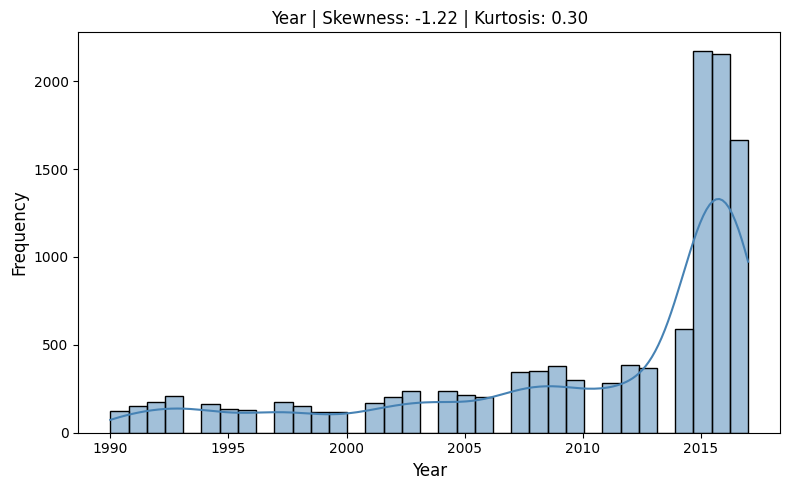

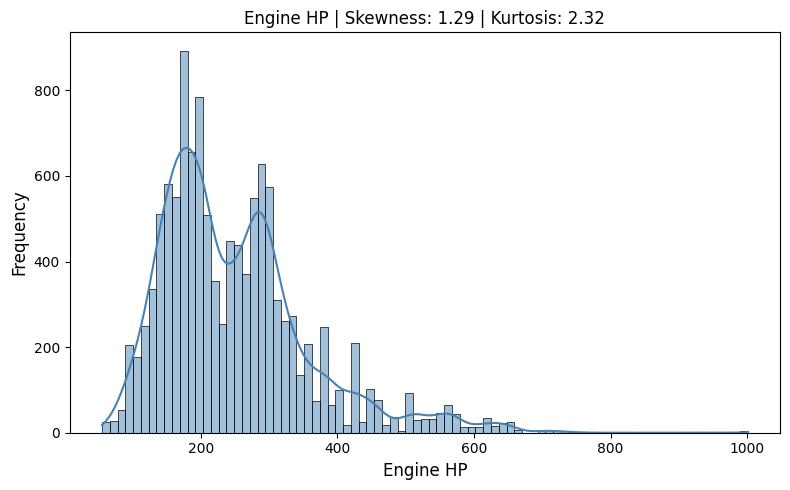

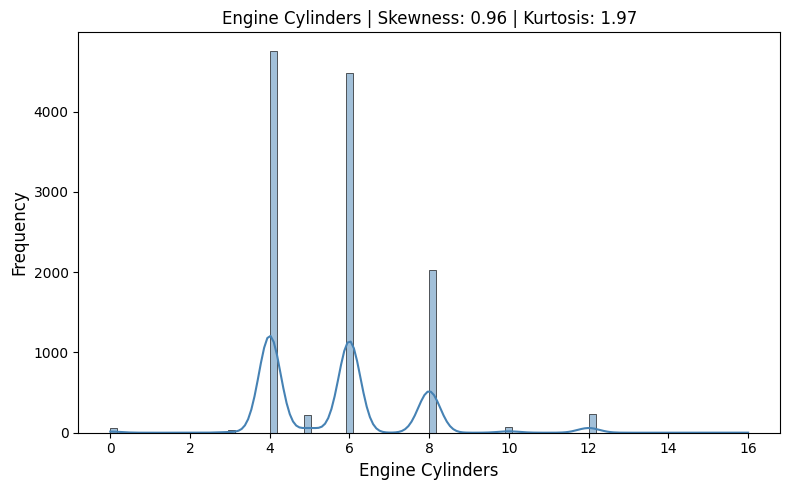

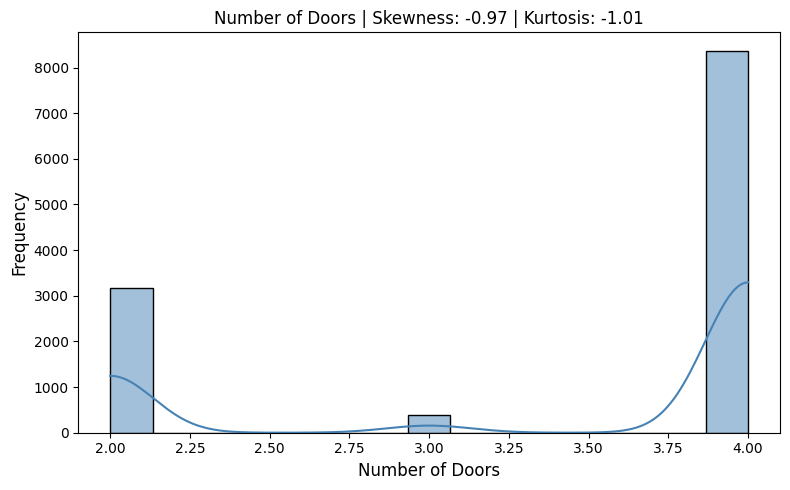

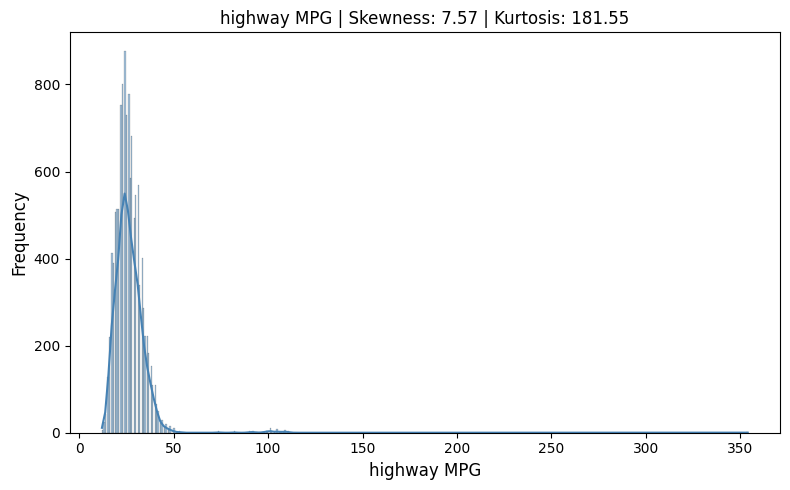

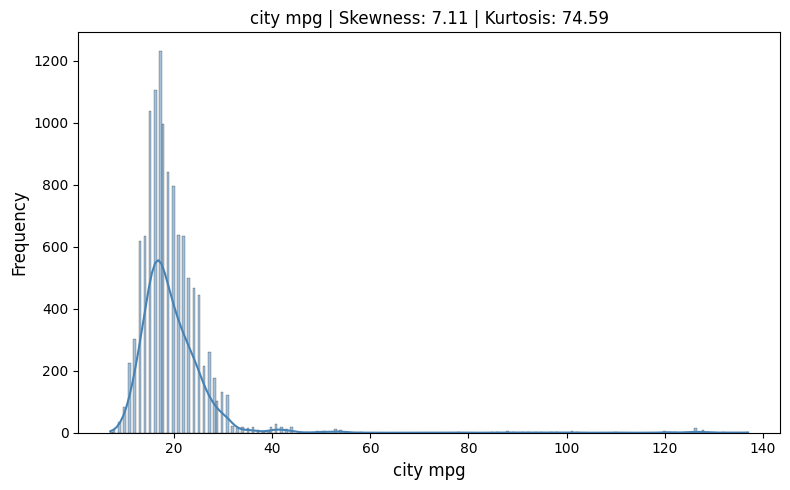

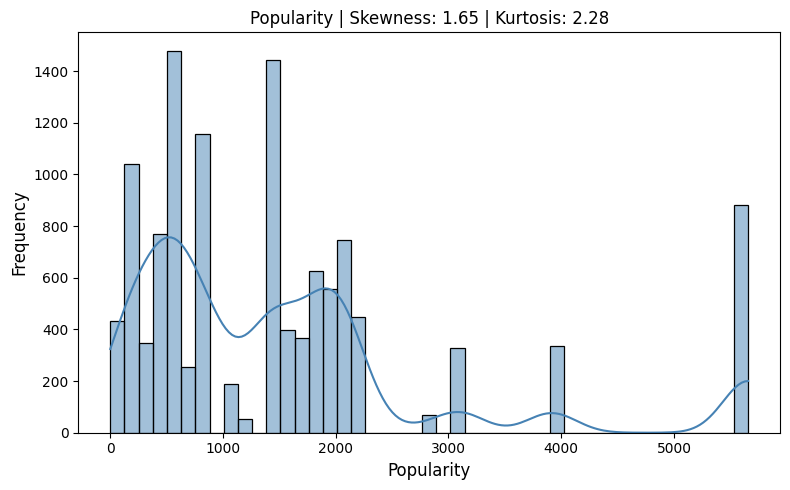

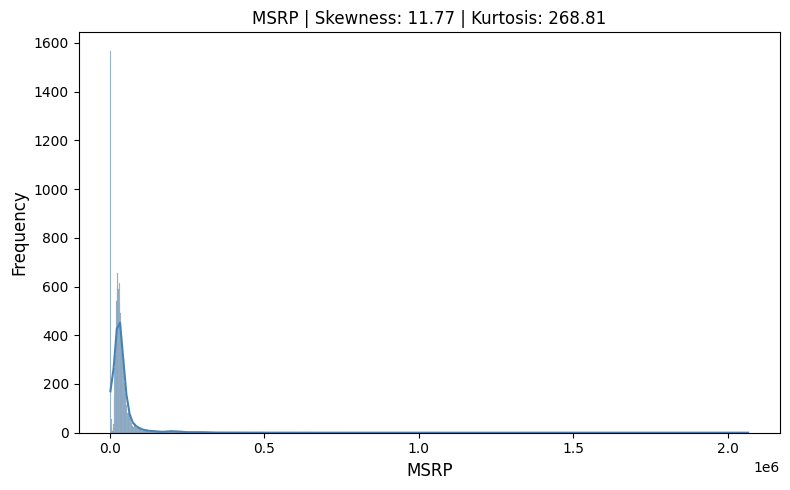

In [4]:
num_cols = df.select_dtypes(include='number').columns # Gets all numerical columns automatically

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, color='steelblue') # drop.na() drops missing values
    
    skewness = stats.skew(df[col].dropna()) # skewness
    kurtosis = stats.kurtosis(df[col].dropna()) # kurtosis
    
    plt.title(f"{col} | Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}", fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.tight_layout()
    plt.show()

## Observations from Univariate Distributions

| Feature | Skewness (γ1) | Kurtosis (γ2) | Distribution Shape |
|---|---|---|---|
| Year | -1.22 | 0.30 | Left-skewed — more recent model years dominate |
| Engine HP | 1.29 | 2.32 | Right-skewed, heavy tails — few high-performance cars pull mean up |
| Engine Cylinders | 0.96 | 1.97 | Slightly right-skewed, heavy tail — most cars have 4-6 cylinders |
| Number of Doors | -0.97 | -1.01 | Slightly left-skewed, light tails — most cars have 4 doors |
| highway MPG | 7.57 | 181.55 | Severely right-skewed, extremely heavy tails — a few hybrid/electric vehicles with implausibly high MPG values |
| city mpg | 7.11 | 74.59 | Severely right-skewed, very heavy tails — same issue as highway MPG |
| Popularity | 1.65 | 2.28 | Right-skewed — few brands dominate Twitter mentions |
| MSRP | 11.77 | 268.81 | Most severely skewed — exotic cars worth millions create extreme right tail |

### Key Takeaways
- **MSRP, highway MPG, and city mpg** are severely right-skewed (γ1 > 1) 
and will require **log transformation** before regression modelling to reduce 
the influence of extreme values.
- **highway MPG (γ2 = 181.55) and MSRP (γ2 = 268.81)** have extremely heavy 
tails indicating dangerous outliers that must be treated in Phase 3.
- **Number of Doors** has light tails (γ2 = -1.01) — values are tightly 
clustered around 2 and 4 with almost no variation.
- **Year** is left-skewed (γ1 = -1.22) — the dataset is heavily biased 
toward recent model years (2010–2017).

## 2.2 Categorical Analysis

This cell plots a bar chart of value counts for every categorical 
feature sorted by frequency, and identifies rare categories 
comprising less than 1% of the data (< 119 rows).

**Note:** The Model column (915 unique values) is excluded from 
visualization as it is essentially an ID column and is not suitable 
for bar chart analysis. It will be dropped during Phase 3 preprocessing.

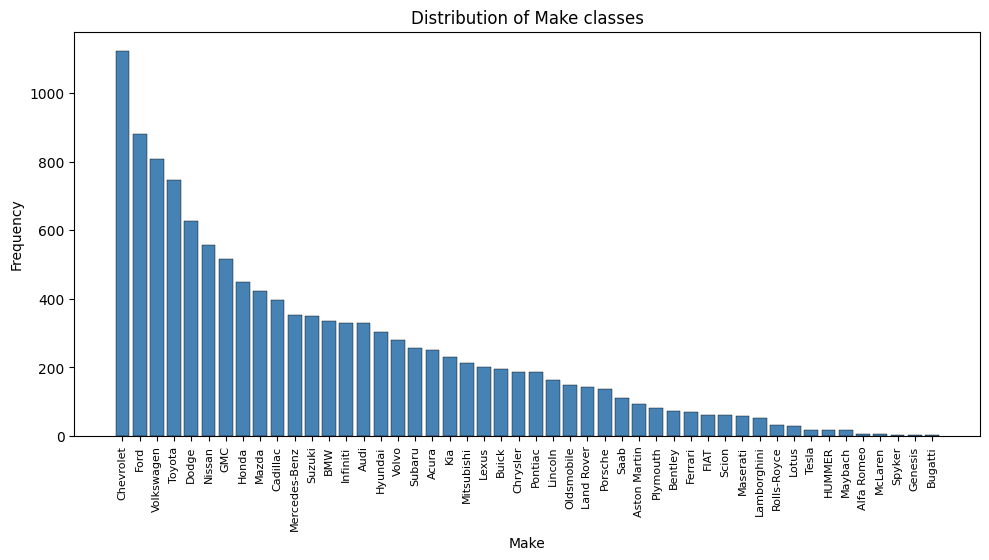


Rare categories in Make (< 1%):
Make
Saab            111
Aston Martin     93
Plymouth         82
Bentley          74
Ferrari          69
FIAT             62
Scion            60
Maserati         58
Lamborghini      52
Rolls-Royce      31
Lotus            29
Tesla            18
HUMMER           17
Maybach          16
Alfa Romeo        5
McLaren           5
Spyker            3
Genesis           3
Bugatti           3
Name: count, dtype: int64


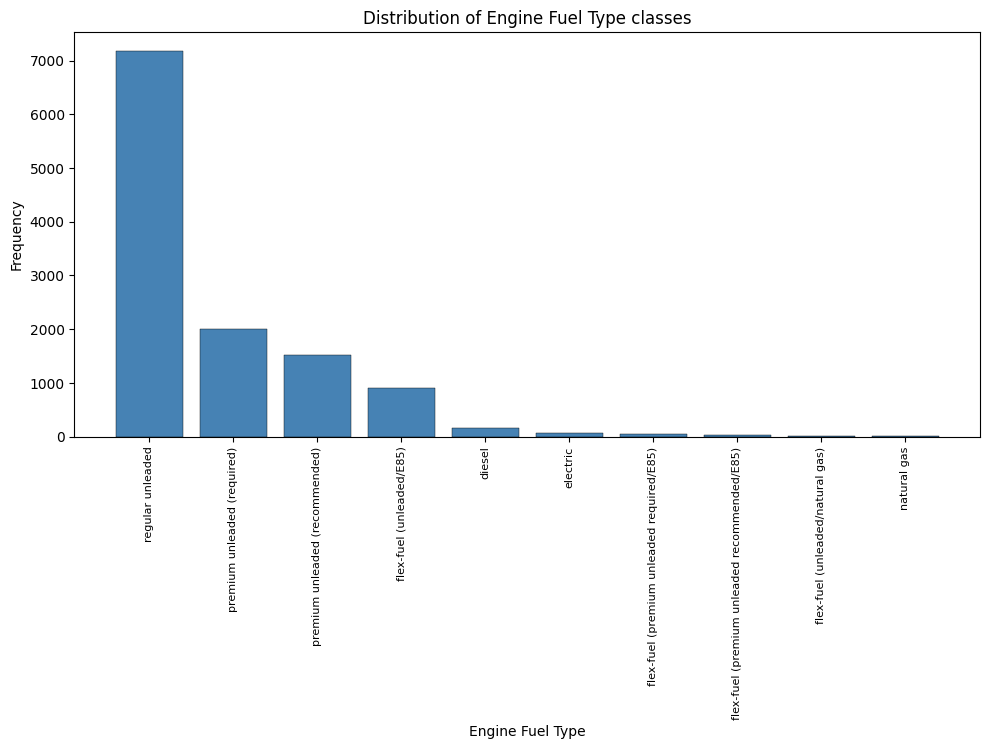


Rare categories in Engine Fuel Type (< 1%):
Engine Fuel Type
electric                                        66
flex-fuel (premium unleaded required/E85)       54
flex-fuel (premium unleaded recommended/E85)    26
flex-fuel (unleaded/natural gas)                 6
natural gas                                      2
Name: count, dtype: int64


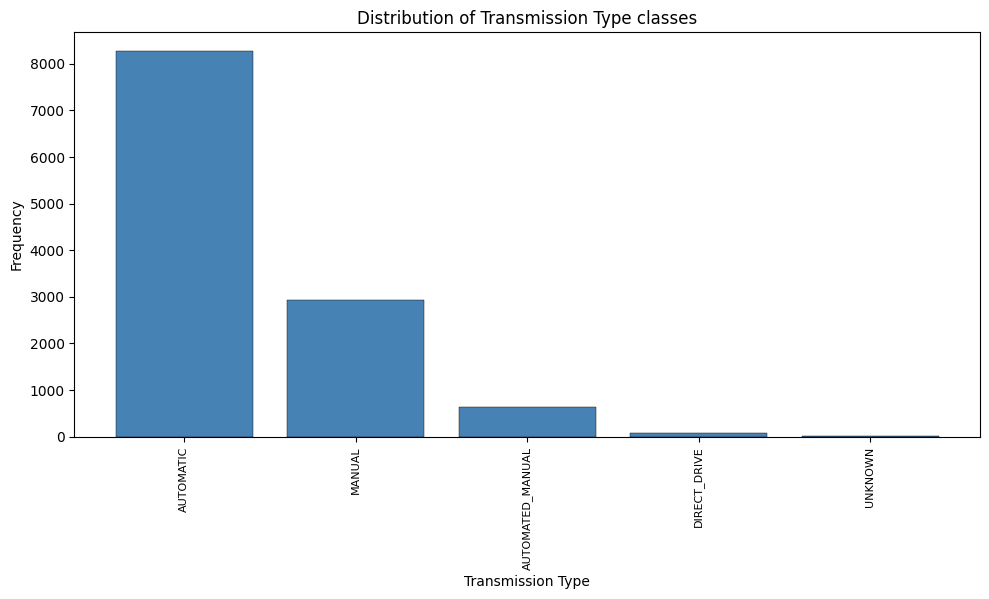


Rare categories in Transmission Type (< 1%):
Transmission Type
DIRECT_DRIVE    68
UNKNOWN         19
Name: count, dtype: int64


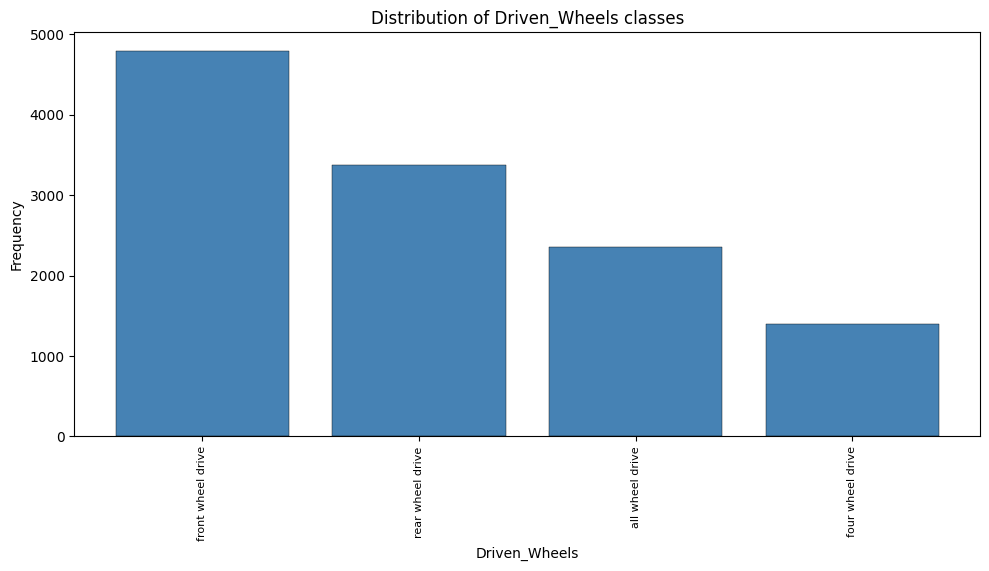

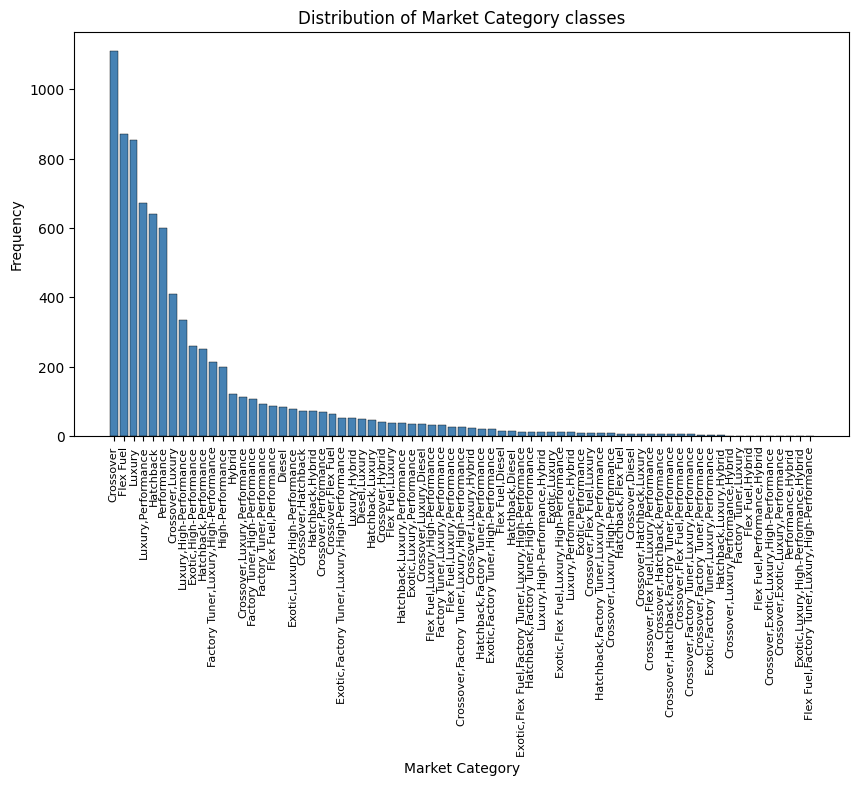


Rare categories in Market Category (< 1%):
Market Category
Crossover,Luxury,Performance                              113
Factory Tuner,High-Performance                            106
Factory Tuner,Performance                                  92
Flex Fuel,Performance                                      87
Diesel                                                     84
Exotic,Luxury,High-Performance                             79
Crossover,Hatchback                                        72
Hatchback,Hybrid                                           72
Crossover,Performance                                      69
Crossover,Flex Fuel                                        64
Exotic,Factory Tuner,Luxury,High-Performance               52
Luxury,Hybrid                                              52
Diesel,Luxury                                              51
Hatchback,Luxury                                           46
Crossover,Hybrid                                           42
Flex Fuel,

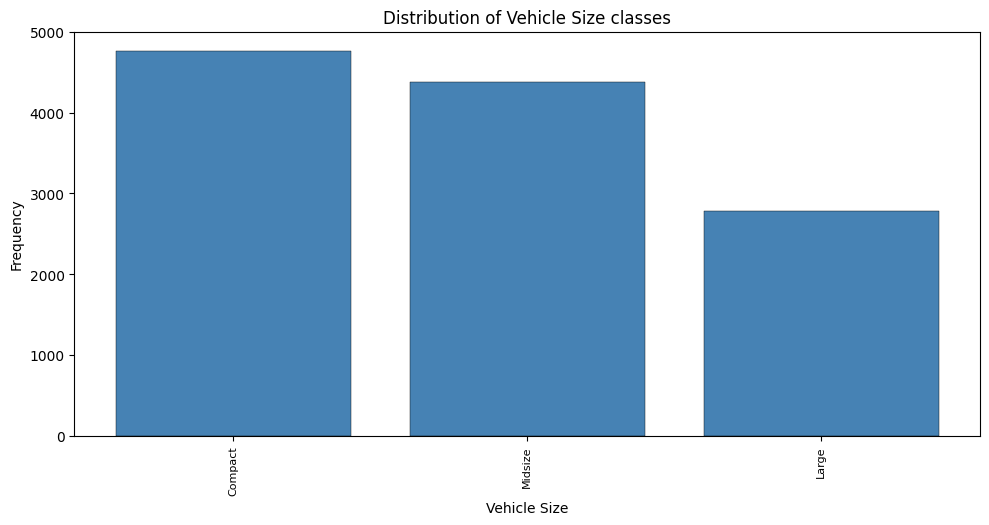

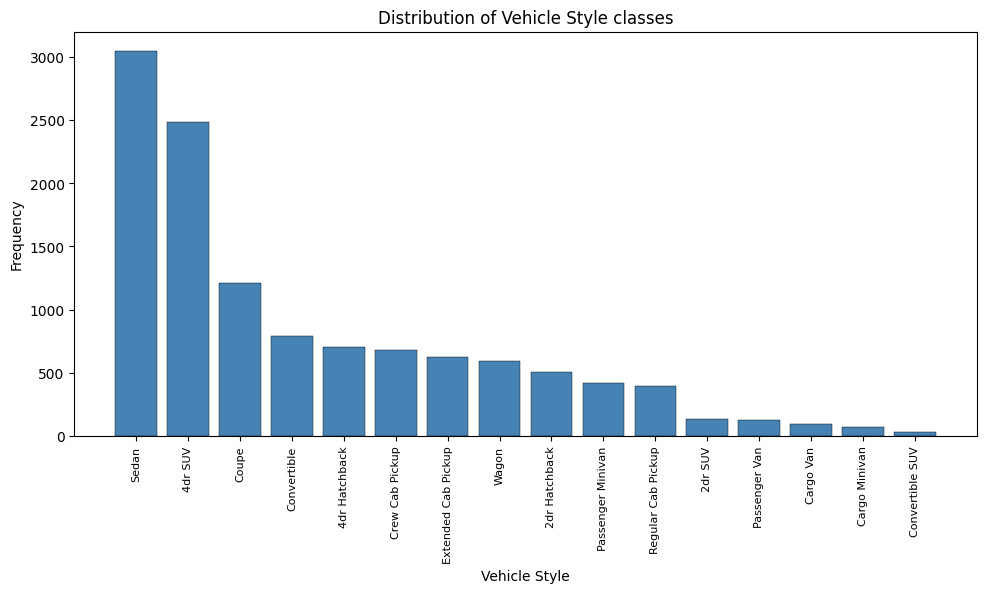


Rare categories in Vehicle Style (< 1%):
Vehicle Style
Cargo Van          95
Cargo Minivan      71
Convertible SUV    29
Name: count, dtype: int64


In [5]:
cat_cols = df.select_dtypes(include='object').columns # Gets all categorical columns automatically

# column to skip — too many unique values
skip_cols = ['Model']

for col in cat_cols:
    if col in skip_cols:
        continue          # skip this column entirely
    
    plt.figure(figsize=(10, 5))
   
    counts = df[col].value_counts()
    
    bars = plt.bar(counts.index, counts.values, color = 'steelblue', edgecolor = 'black', linewidth = 0.3)
    plt.title(f"Distribution of {col} classes", fontsize = 12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.xticks(rotation=90, fontsize=8) # it rotates x-axis labels 90 degrees vertically and makes them smaller so they don't overlap each other
    plt.show()
    
    # Display the rare categories
    rare = counts[counts < 119]
    if len(rare) > 0:
        print(f"\nRare categories in {col} (< 1%):")
        print(rare)

## Observations from Categorical Analysis

### Rare Categories Identified (< 1% of data = < 119 rows)

| Column | Rare Categories | Action in Phase 3 |
|---|---|---|
| **Make** | Saab, Aston Martin, Plymouth, Bentley, Ferrari, FIAT, Scion, Maserati, Lamborghini, Rolls-Royce, Lotus, Tesla, Spyker, Genesis, Bugatti | Group into "Other" category |
| **Engine Fuel Type** | electric, flex-fuel variants, natural gas | Group into "Other" category |
| **Transmission Type** | DIRECT_DRIVE, UNKNOWN | Group into "Other" or drop |
| **Market Category** | 40+ rare combinations | Drop column — too many unique combinations |
| **Vehicle Style** | Cargo Van, Cargo Minivan, Convertible SUV | Group into "Other" category |

### Key Observations

- **Make** is heavily dominated by Chevrolet (1,123 cars) — 15 out of 48 
brands are rare and will need grouping.
- **Engine Fuel Type** is dominated by regular unleaded (7,172 cars = 60%) — 
5 fuel types are rare including electric vehicles.
- **Transmission Type** is dominated by AUTOMATIC (8,266 cars = 69%) — 
DIRECT_DRIVE and UNKNOWN are rare and will be grouped.
- **Market Category** has 71 unique combinations — extremely high cardinality. 
This column will be dropped in Phase 3 or frequency encoded.
- **Vehicle Size** is well balanced — Compact (4,764), Midsize (4,386), 
Large (2,764) — confirming our classification target is suitable.
- **Vehicle Style** has 3 rare body types that will be grouped into "Other" 
during Phase 3 encoding.
- **Driven Wheels** and **Vehicle Style** show no surprising distributions — 
front wheel drive dominates as expected for a US market dataset.

## 2.3 Correlation Matrix

This cell computes the Pearson correlation matrix for all numerical 
features and visualizes it as an annotated heatmap.

### Pearson Correlation Formula
The Pearson correlation coefficient between two variables x and y:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

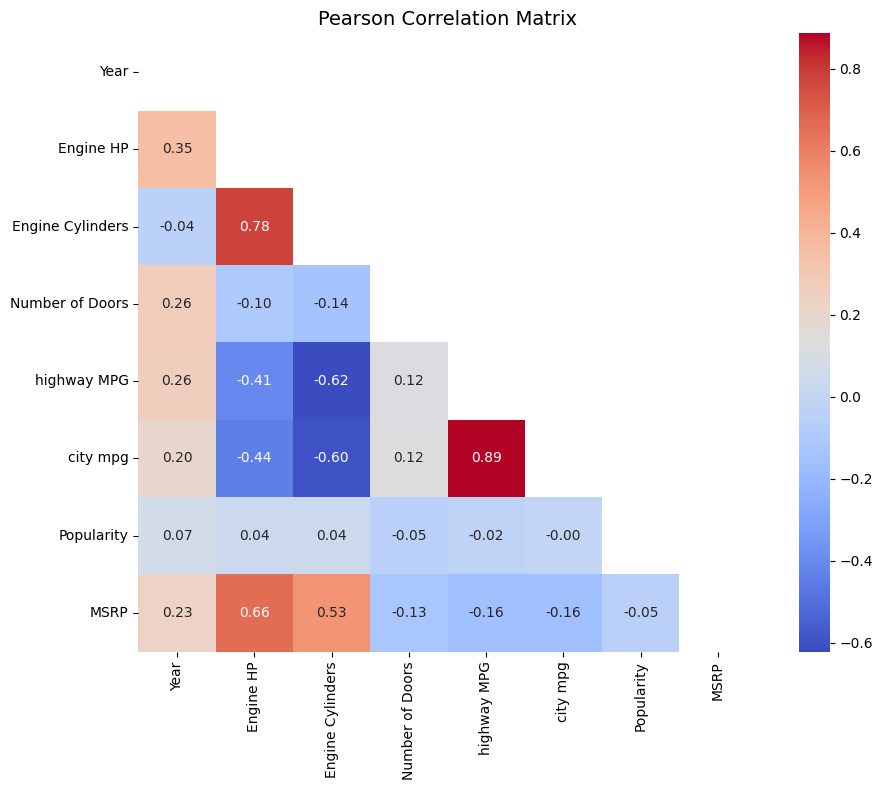

In [6]:
# Select all numerical columns at once and find their correlation with each other
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr)) # mask hides the upper triangle of the correlation matrix to avoid showing the same correlation value twice

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## Observations from Correlation Matrix

### Top 3 Positive Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| Engine HP | 0.66 | Strong positive — more powerful engines cost more |
| Engine Cylinders | 0.53 | Moderate positive — more cylinders means higher price |
| Year | 0.23 | Weak positive — newer models tend to cost more |

### Top 3 Negative Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| city mpg | -0.16 | Weak negative — fuel efficient cars tend to be cheaper |
| highway MPG | -0.16 | Weak negative — same pattern as city mpg |
| Number of Doors | -0.13 | Weak negative — more doors slightly associated with lower price |

### Multicollinearity Warning — |r| > 0.8
| Feature Pair | Correlation | Action |
|---|---|---|
| highway MPG vs city mpg | **0.89** | Strong multicollinearity — these two features are nearly identical. One may need to be dropped in Phase 5 to avoid destabilising regression coefficients |
| Engine HP vs Engine Cylinders | **0.78** | Approaching multicollinearity threshold — monitor carefully |

### Key Takeaway
Engine HP is the strongest predictor of MSRP (r = 0.66), confirming 
that more powerful cars are significantly more expensive. The near-perfect 
correlation between highway MPG and city mpg (r = 0.89) indicates 
redundant features that will be addressed during feature selection in Phase 5.

## 2.4 Bivariate Plots

This section produces three types of bivariate plots: scatter plots of top 5 
features vs MSRP with trend lines, box plots of numerical features grouped by 
Vehicle Size, and a pair plot of top 5 features coloured by Vehicle Size.

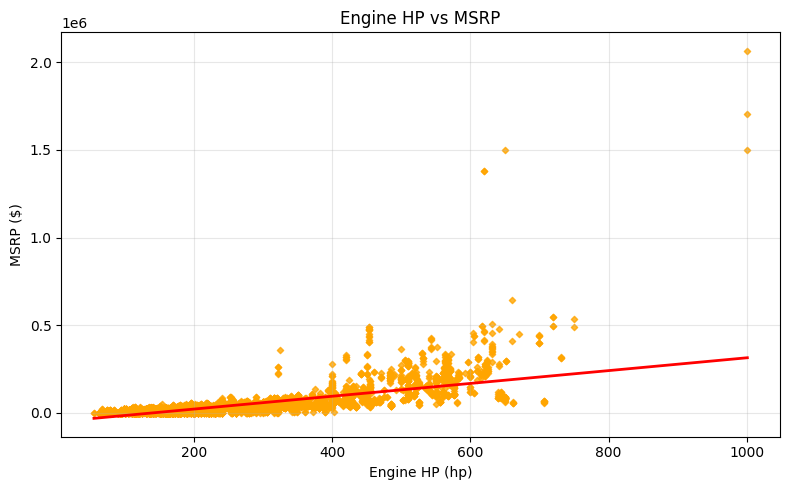

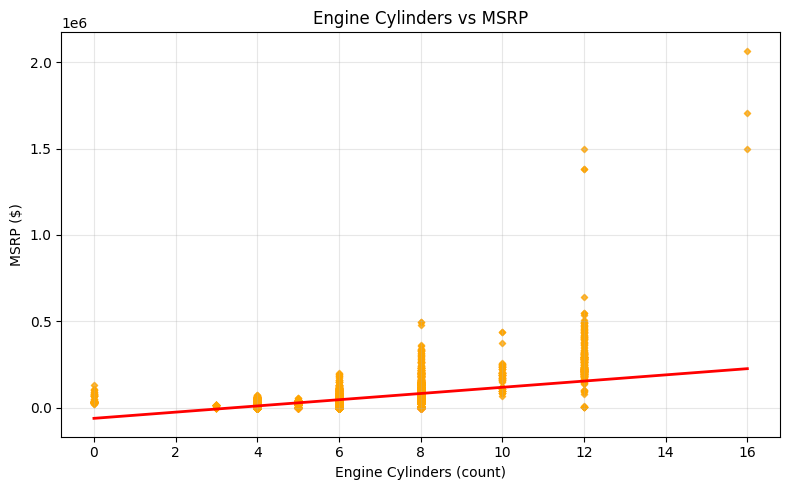

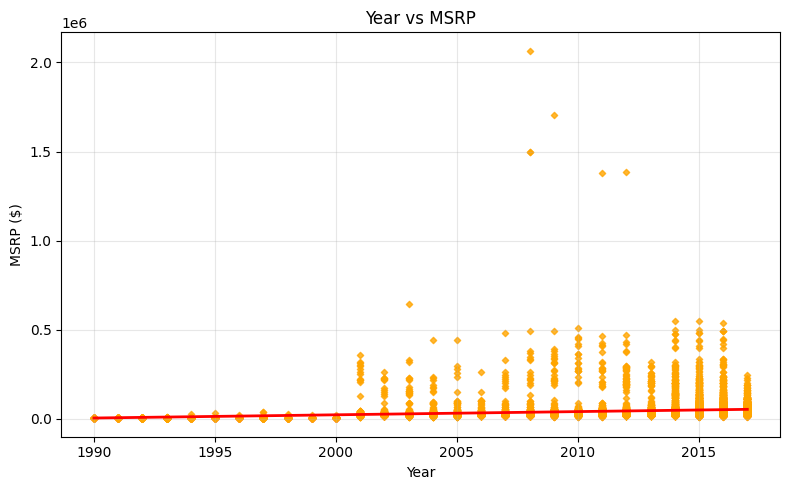

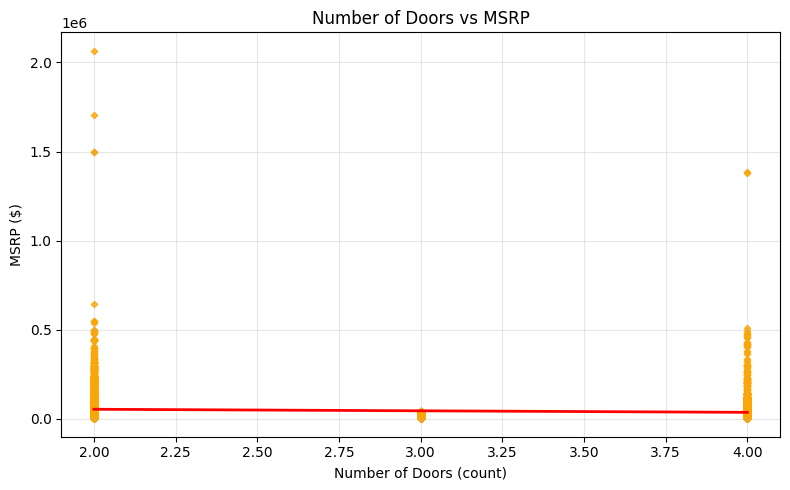

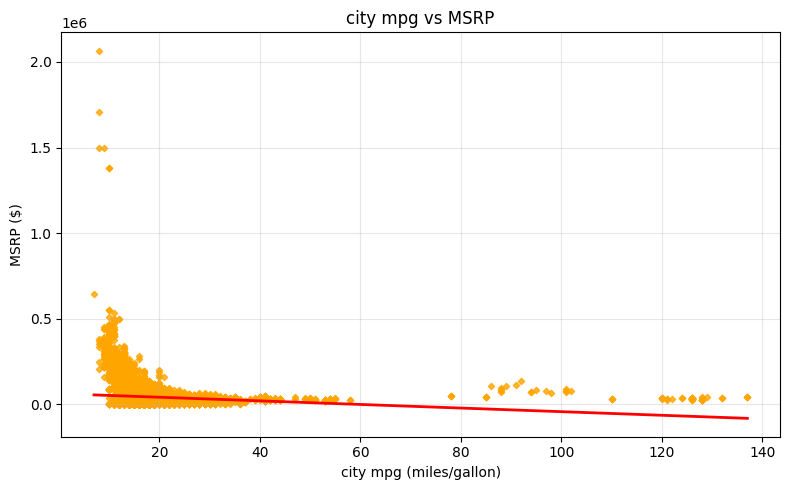

In [7]:
# Scatter Plot of top 5 features with MSRP
# Based on their correlation
top5_features= {
    'Engine HP': 'Engine HP (hp)',
    'Engine Cylinders': 'Engine Cylinders (count)',
    'Year': 'Year',
    'Number of Doors': 'Number of Doors (count)',
    'city mpg': 'city mpg (miles/gallon)'
}

for feature in top5_features:
    temp = df[[feature, 'MSRP']].dropna()  # drop missing from both simultaneously to make them equally sized
    
    plt.figure(figsize=(8, 5))
    plt.scatter(temp[feature], temp["MSRP"], 
                color='orange',
                alpha=0.8,
                s=10,
                marker='D')
    
    # Trend line (best fit straight line)
    coeffs = np.polyfit(temp[feature], temp['MSRP'], deg=1) # returns slope and c
    trend = np.poly1d(coeffs) # converts coefficients into a callable mathematical function
    x_sorted = np.sort(temp[feature]) # to avoid zig zag line
    plt.plot(x_sorted, trend(x_sorted), color='red', linewidth=2) # inspect the plot
    
    plt.title(f"{feature} vs MSRP")
    plt.xlabel(top5_features[feature])
    plt.ylabel("MSRP ($)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() 

### Observations from Scatter Plots

| Feature | Trend | Interpretation |
|---|---|---|
| Engine HP vs MSRP | ↗ Positive | Strong upward trend confirms r = 0.66 — more powerful engines cost significantly more |
| Engine Cylinders vs MSRP | ↗ Positive | Upward trend confirms r = 0.53 — more cylinders associated with higher price |
| Year vs MSRP | ↗ Weak positive | Slight upward trend confirms r = 0.23 — newer models tend to cost more |
| Number of Doors vs MSRP | → Flat | Almost no trend confirms r = -0.13 — number of doors has negligible effect on price |
| city mpg vs MSRP | ↘ Negative | Downward trend confirms r = -0.16 — fuel efficient cars tend to be cheaper |

**Outlier Note:** Extreme MSRP outliers (exotic cars > $500,000 such as Bugatti 
and Lamborghini) are visible in all scatter plots as isolated dots at the top. 
These pull the trend lines upward making them less representative of the majority 
of cars. These outliers will be treated during Phase 3 using IQR method before 
regression modelling in Phase 6.

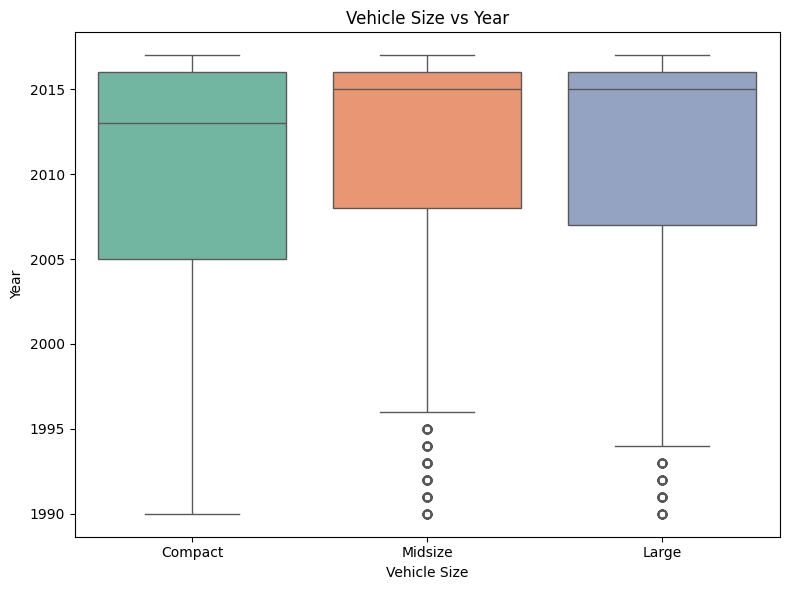

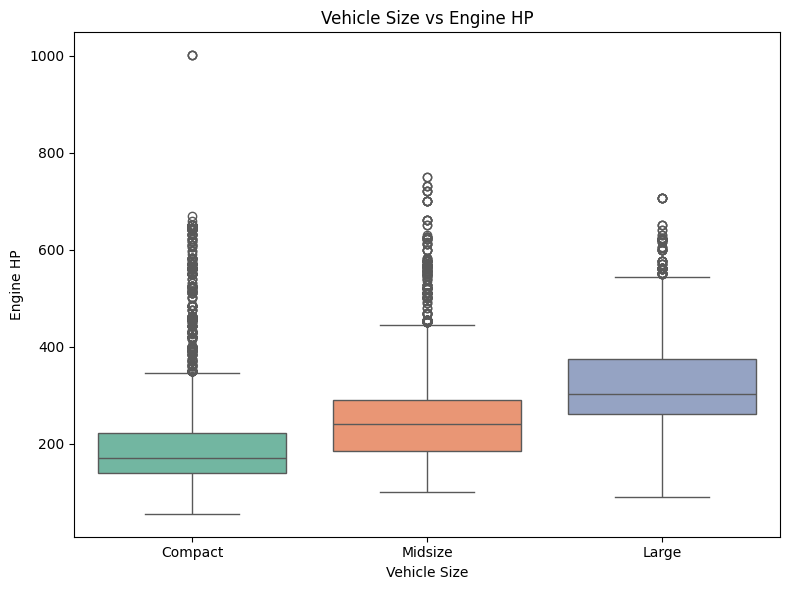

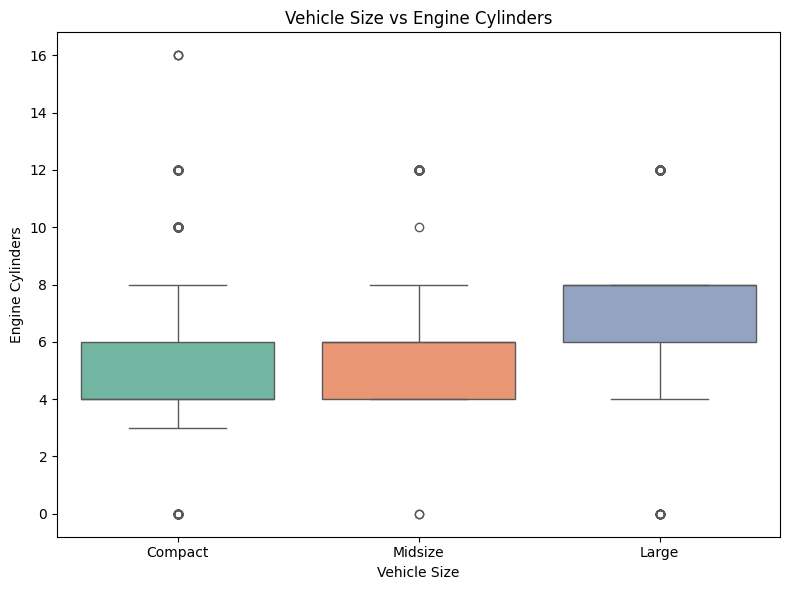

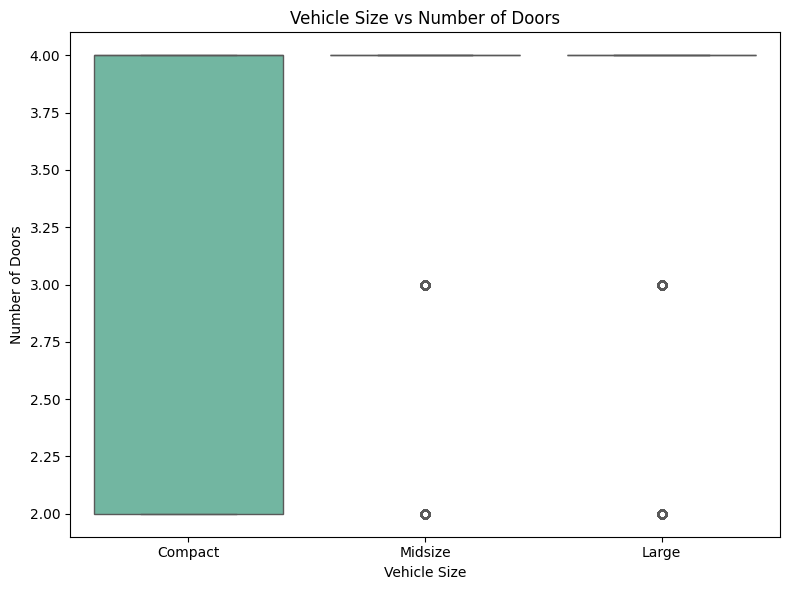

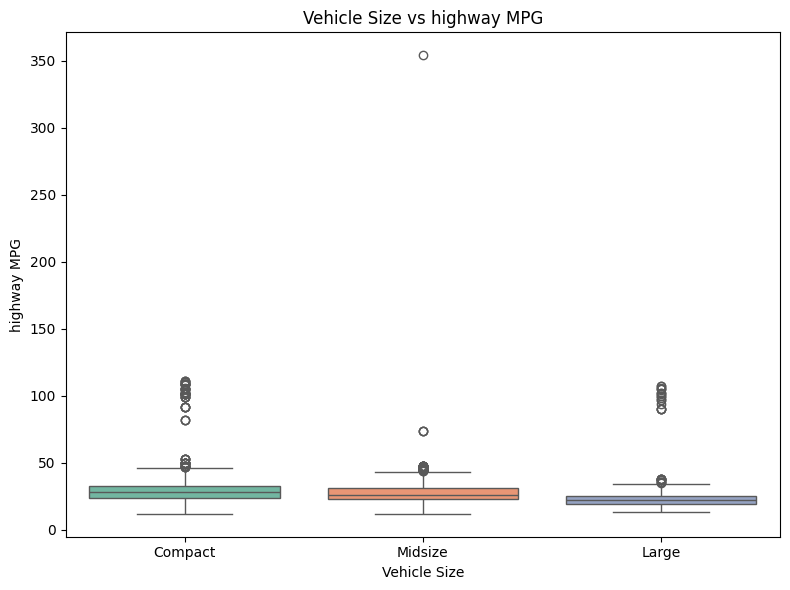

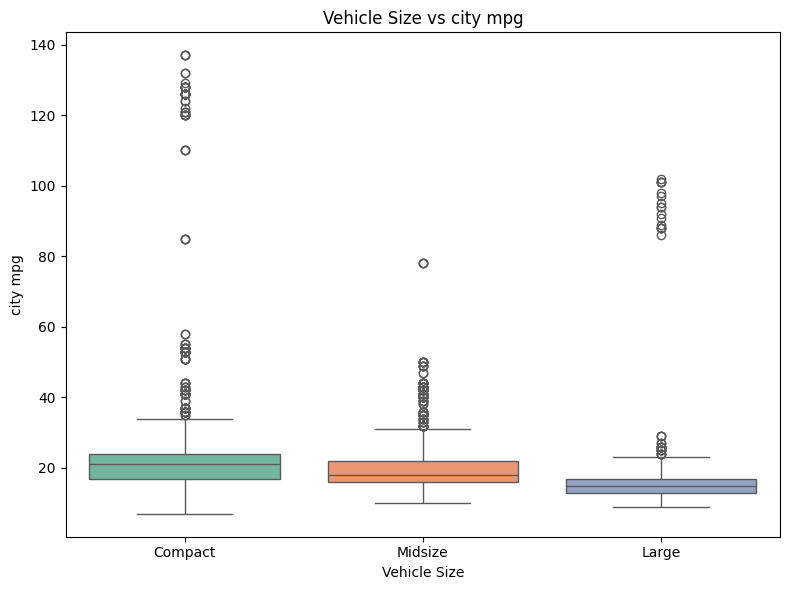

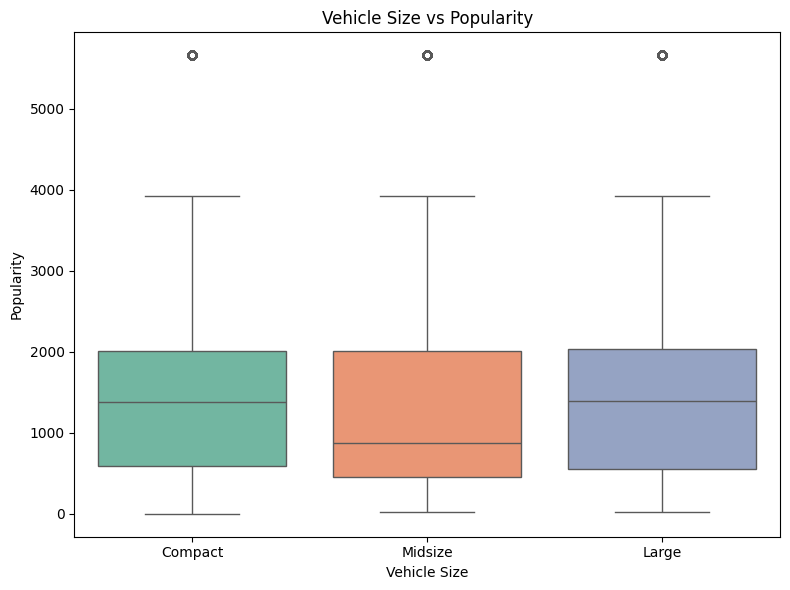

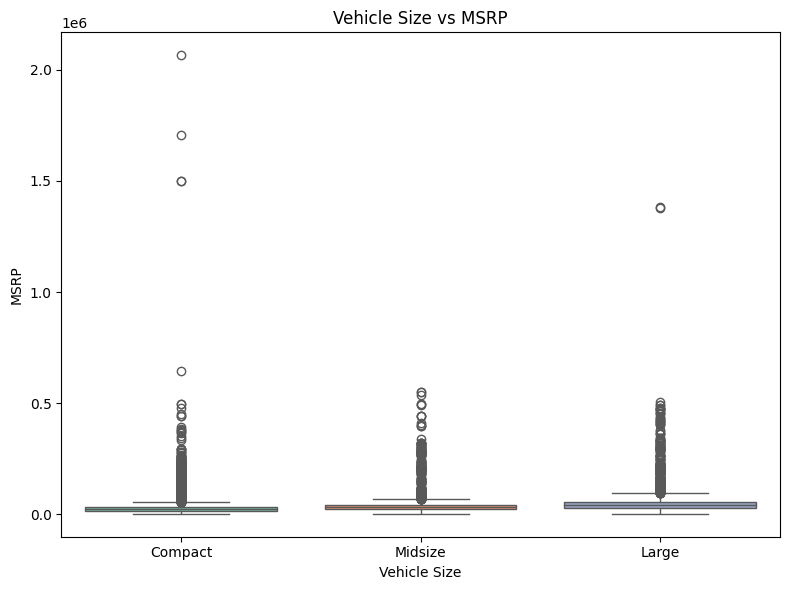

In [8]:
# Box plot of each numerical feature grouped by classification target
num_cols = df.select_dtypes(include="number").columns

for feature in num_cols:
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Vehicle Size', y=feature, data=df, 
            hue='Vehicle Size', palette='Set2', legend=False)
    
    plt.title(f"Vehicle Size vs {feature}")
    plt.xlabel("Vehicle Size")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## Observations from Box Plots

| Feature | Separation Between Classes | Useful for Classification? |
|---|---|---|
| Engine HP |  Clear — Large cars have highest HP (median ~300), Compact lowest (~180) |  Yes |
| Engine Cylinders |  Clear — Large cars have more cylinders (median ~7), Compact fewer (~5) |  Yes |
| highway MPG |  Moderate — Compact cars are more fuel efficient than Large |  Yes |
| city mpg |  Moderate — Compact slightly higher mpg than Large |  Yes |
| Year |  Poor — all three classes have similar year distributions |  No |
| Number of Doors |  Poor — almost no variation across classes |  No |
| Popularity |  Poor — boxes heavily overlap across all three classes |  No |
| MSRP |  Poor — extreme outliers dominate, boxes too compressed to compare |  No |

### Key Takeaway
**Engine HP and Engine Cylinders** show the clearest separation between 
Compact, Midsize and Large vehicles — these will likely be the most 
important features for the classification model in Phase 7. 
**Year, Number of Doors, and Popularity** show almost no separation 
between classes and may not contribute meaningfully to classification.

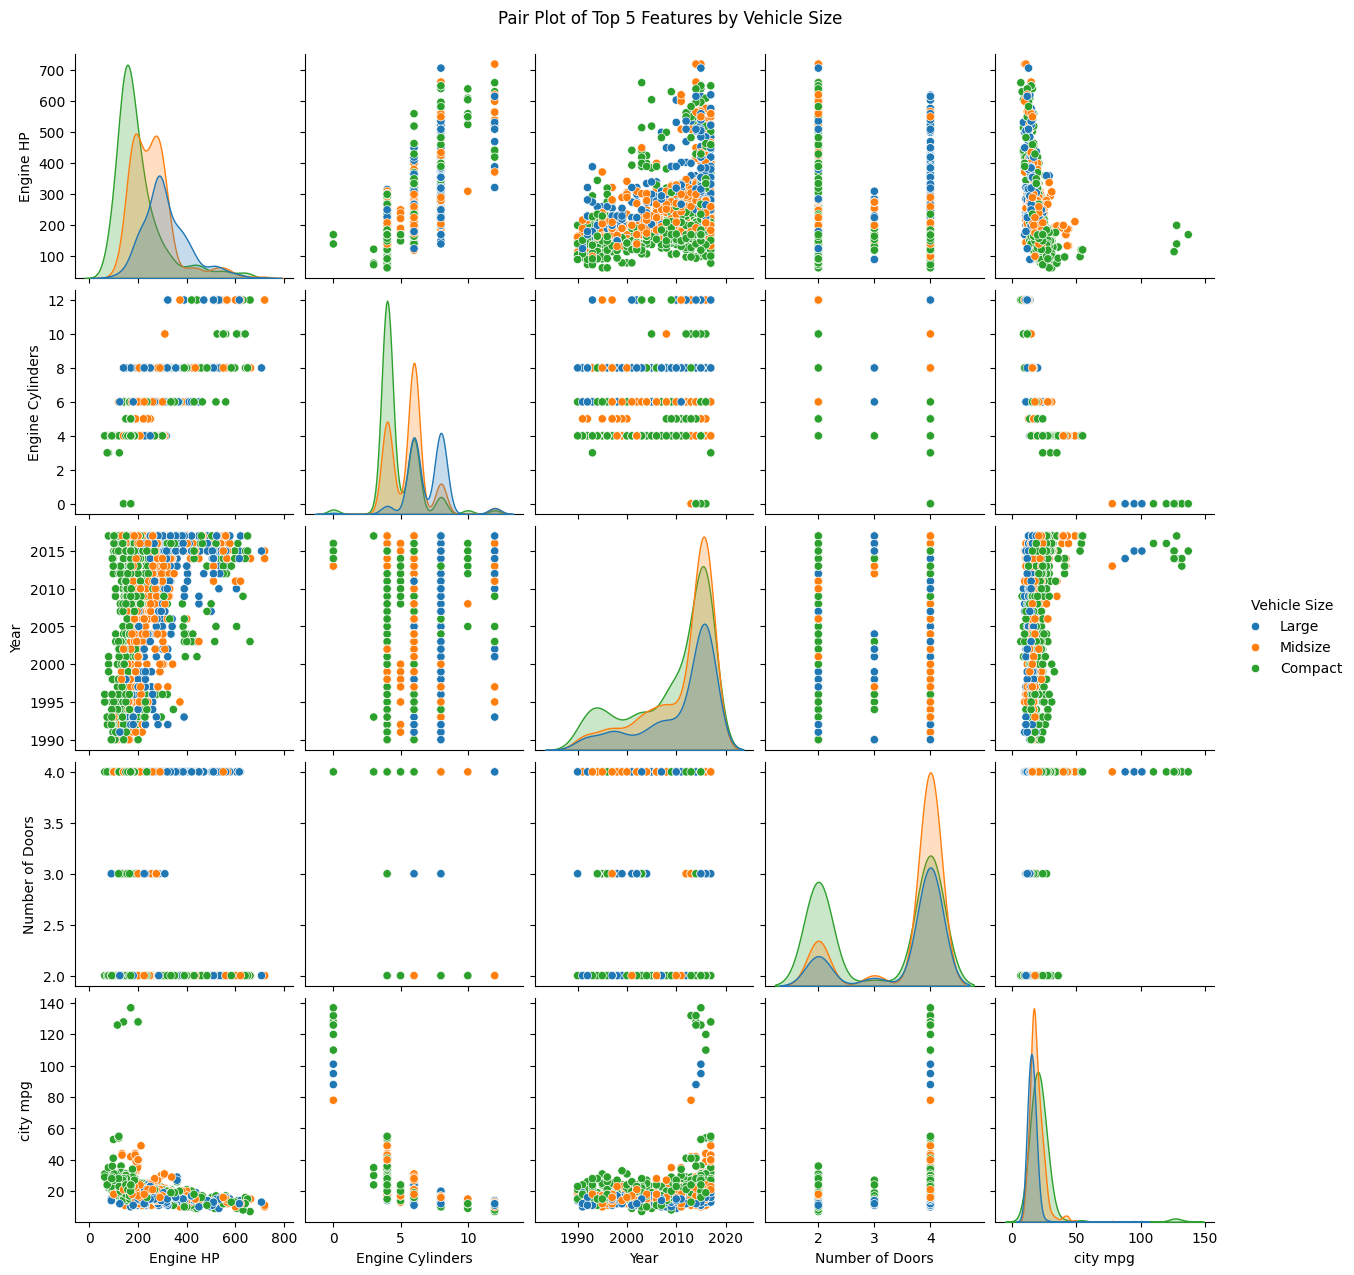

In [9]:
# Pair plot ( Relationships between every pair of numerical features + their individual distributions) of top 5 correlated features
df_sample = df.sample(2000, random_state=42) # sample upto 2000 rows for the pair plot
  
sns.pairplot(df_sample, vars=list(top5_features.keys()), hue='Vehicle Size')
plt.suptitle("Pair Plot of Top 5 Features by Vehicle Size", 
             y=1.02, fontsize=12)

plt.show()

### Pair Plot — Top 5 Features by Vehicle Size

The pair plot reveals that **Engine HP and Engine Cylinders** are the strongest 
individual features for separating Vehicle Size classes — their diagonal KDE 
plots show three distinct peaks for Compact, Midsize and Large. Together, 
Engine HP and Engine Cylinders show clear color clustering in their scatter 
plot with Large cars (blue) concentrated at high HP and high cylinder values 
while Compact cars (green) cluster at lower values. In contrast, **Year and 
Number of Doors** show completely mixed colors in all scatter plots indicating 
they cannot distinguish between vehicle sizes. These findings will directly 
guide feature selection in Phase 5 and model building in Phase 7.

## 2.5 Temporal or spatial patterns

This section substitutes the temporal/spatial plot since the dataset contains 
no timestamp or location column. Instead, violin plots of the two most 
interesting features (Engine HP and MSRP) are produced, stratified by 
Vehicle Size classification target.

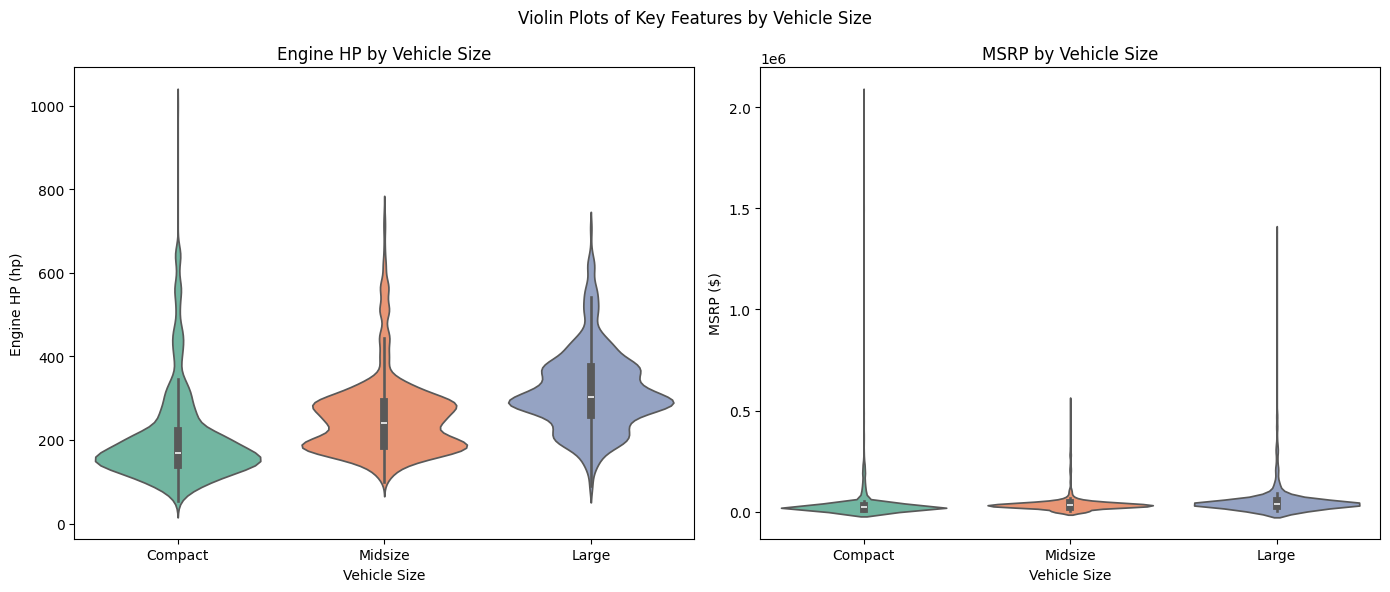

In [10]:
# Violin plot (box plot + histogram) of Engine HP and MSRP, stratified by classification target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Engine HP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='Engine HP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Engine HP by Vehicle Size")
axes[0].set_xlabel("Vehicle Size")
axes[0].set_ylabel("Engine HP (hp)")

# Plot 2 — MSRP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='MSRP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("MSRP by Vehicle Size")
axes[1].set_xlabel("Vehicle Size")
axes[1].set_ylabel("MSRP ($)")

plt.suptitle("Violin Plots of Key Features by Vehicle Size", fontsize=12)
plt.tight_layout()
plt.show()

## Observations from Violin Plots

**Engine HP violin plot** shows three clearly separated distributions — 
Compact cars are widest around 150–200 HP, Midsize around 200–250 HP, 
and Large around 300 HP with three distinct medians. This confirms that 
Engine HP is a strong differentiator between vehicle size classes.

**MSRP violin plot** shows three violins with almost identical medians 
compressed at the bottom — all three classes have similar price distributions 
with extreme outliers stretching upward. This confirms that MSRP alone 
cannot effectively differentiate between vehicle size classes and is heavily 
influenced by exotic car outliers that will be treated in Phase 3.

**Key Takeaway:** Vehicle Size is best differentiated by Engine HP rather 
than MSRP — Engine HP produces three clearly distinct medians across classes 
while MSRP medians are almost identical across all three vehicle sizes.

## 2.6 EDA Summary Narrative

Exploratory data analysis of the automotive dataset revealed five critical 
findings that will directly inform modelling decisions in later phases.

**Finding 1 — Severe Right Skewness in Key Features:**
MSRP (γ1 = 11.77), highway MPG (γ1 = 7.57), and city mpg (γ1 = 7.11) 
are severely right-skewed, indicating that a small number of extreme values 
— such as exotic cars and electric vehicles — dominate these distributions. 
Log transformation will be applied to MSRP before regression modelling.

**Finding 2 — Extreme Heavy Tails Indicating Dangerous Outliers:**
MSRP (γ2 = 268.81) and highway MPG (γ2 = 181.55) show extremely heavy 
tails confirming the presence of dangerous outliers. In contrast, Number 
of Doors (γ2 = -1.01) has light tails with values tightly clustered 
around 2 and 4. These outliers will be treated using IQR method in Phase 3.

**Finding 3 — Strong Correlations with MSRP:**
Engine HP (r = 0.66) and Engine Cylinders (r = 0.53) show the strongest 
positive correlations with MSRP — more powerful engines with more cylinders 
are significantly more expensive. Highway MPG (r = -0.16) and city mpg 
(r = -0.16) show weak negative correlations — fuel efficient cars tend 
to be cheaper. A critical multicollinearity warning was identified between 
highway MPG and city mpg (r = 0.89) — these two features are nearly 
identical and one may need to be dropped in Phase 5.

**Finding 4 — Extreme MSRP Outliers Distorting Analysis:**
Exotic cars such as Bugatti and Lamborghini with MSRP > $500,000 appear 
as isolated dots in all scatter plots, pulling trend lines upward and 
making them less representative of the majority of cars priced between 
$20,000–$40,000. These outliers will be treated in Phase 3 using IQR 
method before regression modelling in Phase 6.

**Finding 5 — Engine HP Best Differentiates Vehicle Size Classes:**
Box plots and violin plots confirm that Engine HP produces three clearly 
distinct medians across vehicle size classes — Compact (~180 HP), 
Midsize (~240 HP), and Large (~300 HP). In contrast, Year, Number of 
Doors, and Popularity show almost no separation between classes and will 
likely contribute minimally to the classification model in Phase 7. 
Pair plot analysis further confirms that Engine HP and Engine Cylinders 
together provide the strongest visual separation between Compact, 
Midsize and Large vehicles.

# Phase 3: Data Cleaning & Preprocessing

In [11]:
# Reload fresh copy of dataset for Phase 3
df = pd.read_csv("data.csv")

## 3.1 Missing Value Audit

This cell computes missing value counts and percentages per column 
and visualizes them as a bar chart with a 40% drop threshold line.

Missing count:
Market Category     3742
Engine HP             69
Engine Cylinders      30
Number of Doors        6
Engine Fuel Type       3
Name: Missing Count, dtype: int64


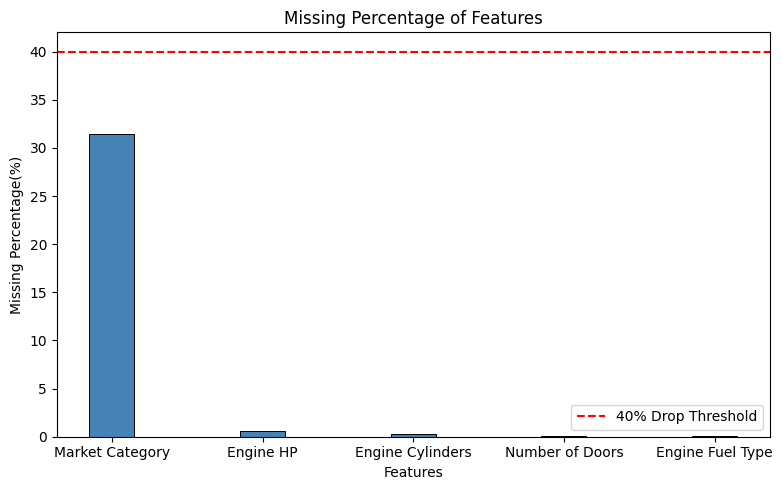

In [12]:
# Count missing values and missing percent per column
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Convert to dataframe
missing_df = pd.DataFrame({
                           'Missing Count': missing_count,
                           'Missing Percentage':missing_percent 
})

# Keep only features that have missing values, sorted by percentage
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

print(f"Missing count:\n{missing_df['Missing Count']}")

# Bar plot of features vs missing percent
plt.figure(figsize=(8, 5))
plt.bar(missing_df.index, missing_df['Missing Percentage'], width=0.3, color='steelblue', edgecolor='black', linewidth=0.7)

# Threshold Line
plt.axhline(y=40, color='red', linestyle = '--', label='40% Drop Threshold')

plt.title('Missing Percentage of Features', fontsize=12)
plt.xlabel('Features')
plt.ylabel('Missing Percentage(%)')
plt.legend()
plt.tight_layout()
plt.show()

## Observations from Missing Value Audit

Market Category has the highest missing percentage at 31.4% — 
below the 40% drop threshold but will be dropped due to high 
cardinality (71 unique combinations) and multi-label format. 
All other columns have less than 1% missing values and will be 
treated with median or mode imputation.

## Missing Value Decision Table

| Column | Missing Count | Missing % | Strategy | Justification |
|---|---|---|---|---|
| Market Category | 3,742 | 31.4% | Drop column | Too many unique combinations (71) making imputation meaningless. Comma separated multiple values in one cell|
| Engine HP | 69 | 0.58% | Median imputation | Right-skewed distribution (γ1 = 1.29) — median is more robust than mean for skewed data |
| Engine Cylinders | 30 | 0.25% | Median imputation | Discrete numerical column — median imputation preserves typical cylinder counts |
| Number of Doors | 6 | 0.05% | Median imputation | Only 6 rows affected — median imputation with negligible impact |
| Engine Fuel Type | 3 | 0.03% | Mode imputation | Categorical column — replace with most frequent category (regular unleaded) |

## Imputations and Dropping

This cell applies the imputations techniques for use in Phase 3.4 and onwards.

In [13]:
# Median imputation
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].median())

# Mode imputation
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0]) # mode returns a series

## 3.2 Outlier Detection and Treatment

This cell applies IQR fences to detect outliers in all numerical columns 
and treats them using Winsorisation, row dropping, or retention based 
on domain knowledge.

IQR Formula:
$$IQR = Q3 - Q1$$
$$Lower = Q1 - 1.5 \times IQR$$
$$Upper = Q3 + 1.5 \times IQR$$


MSRP — IQR: 21231.25, Lower: -10846.88, Upper: 74078.12


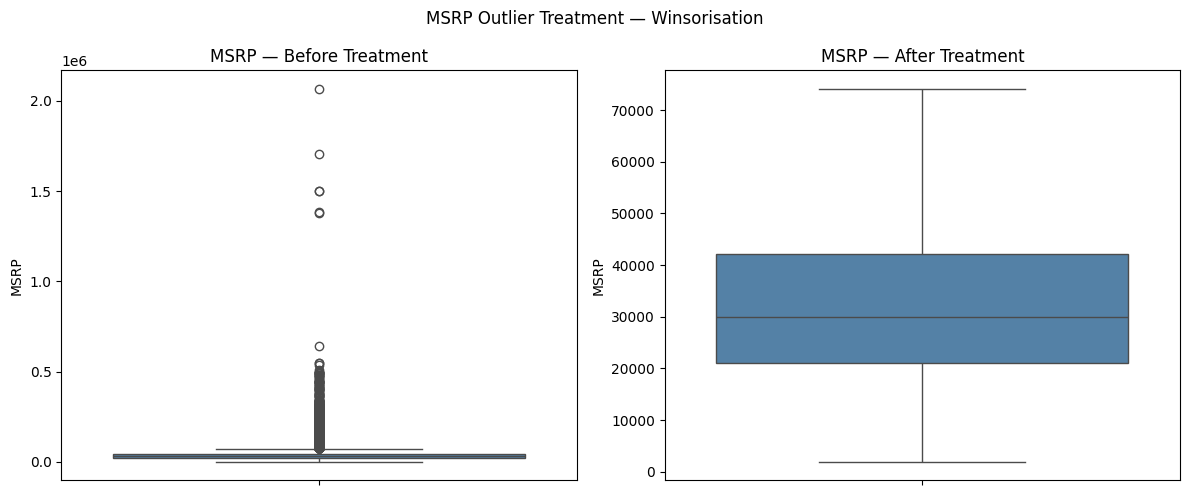


Engine HP — IQR: 130.00, Lower: -25.00, Upper: 495.00


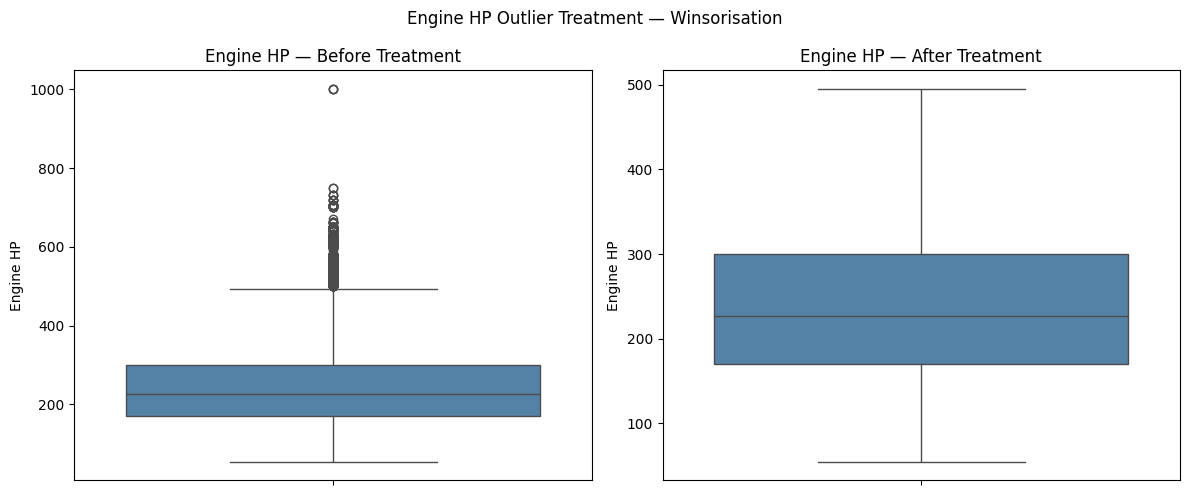


Popularity — IQR: 1460.00, Lower: -1641.00, Upper: 4199.00


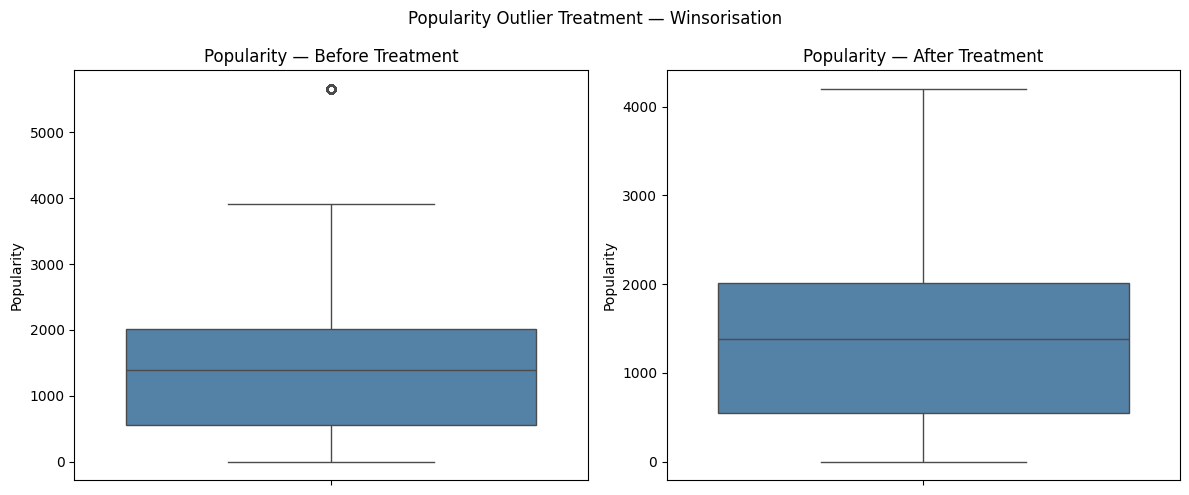


highway MPG — IQR: 8.00, Lower: 10.00, Upper: 42.00


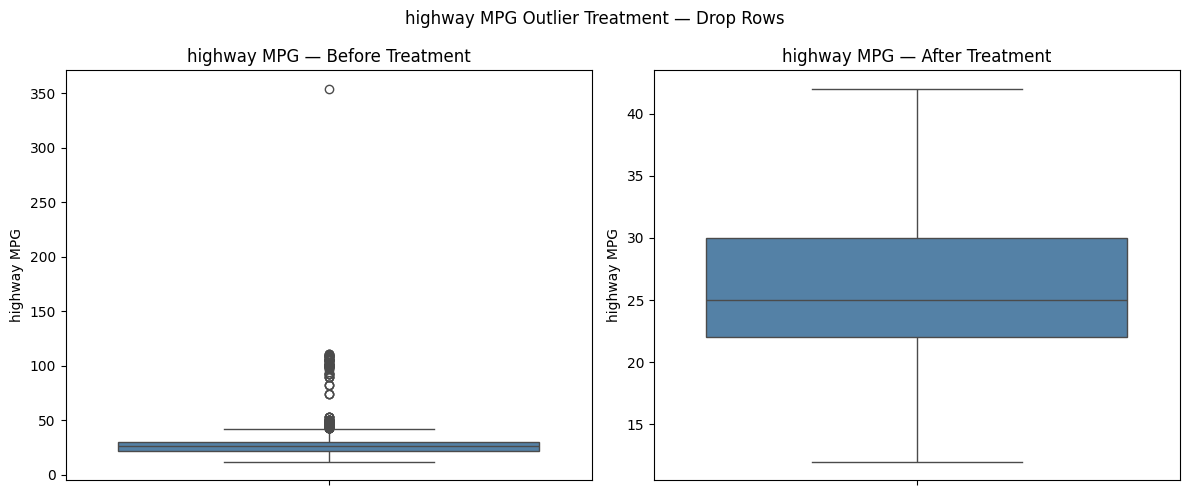


city mpg — IQR: 7.00, Lower: 4.50, Upper: 32.50


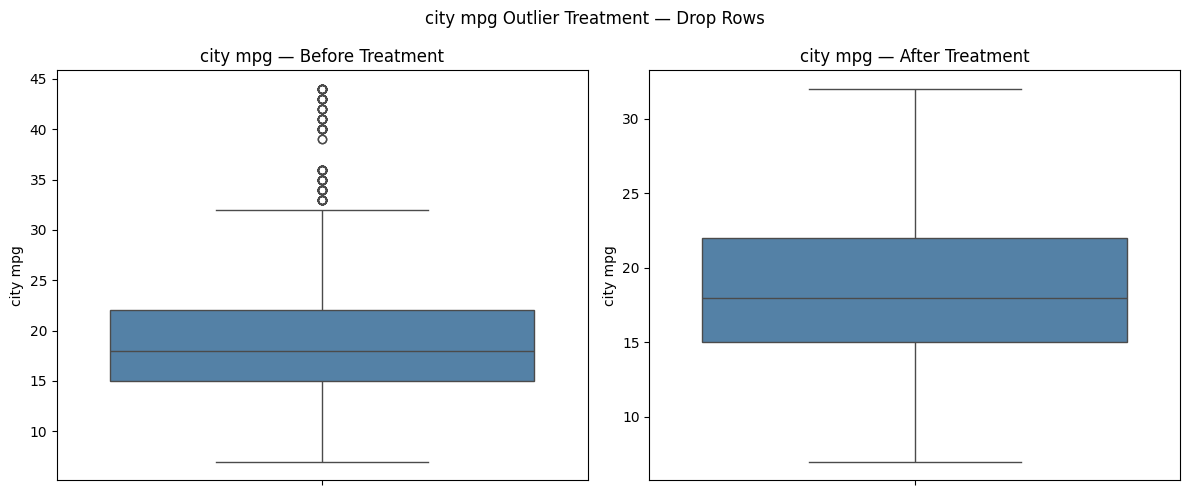


Engine Cylinders — Rows with 0: 0


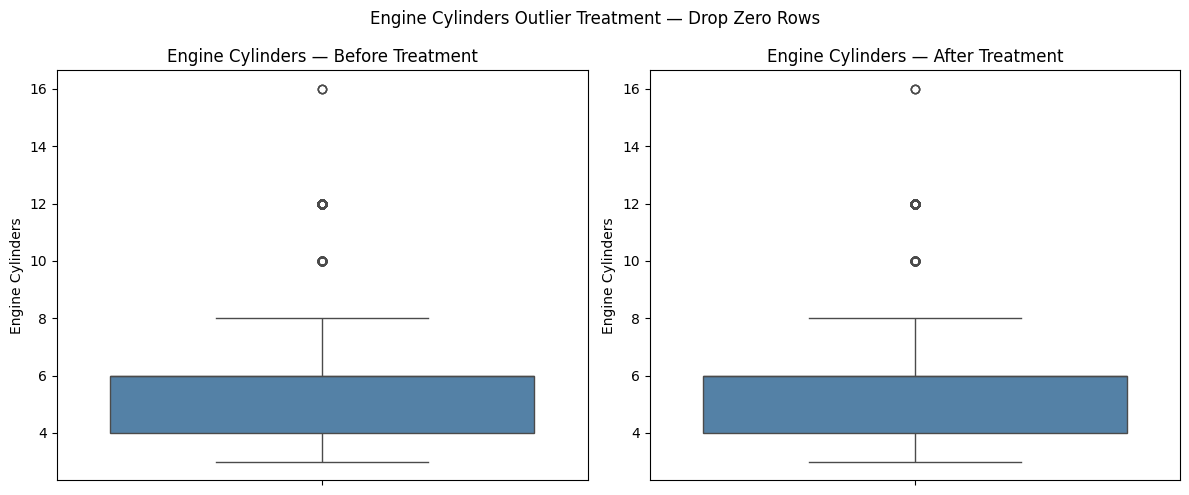


Year — IQR: 10.00, Lower: 1991.00, Upper: 2031.00


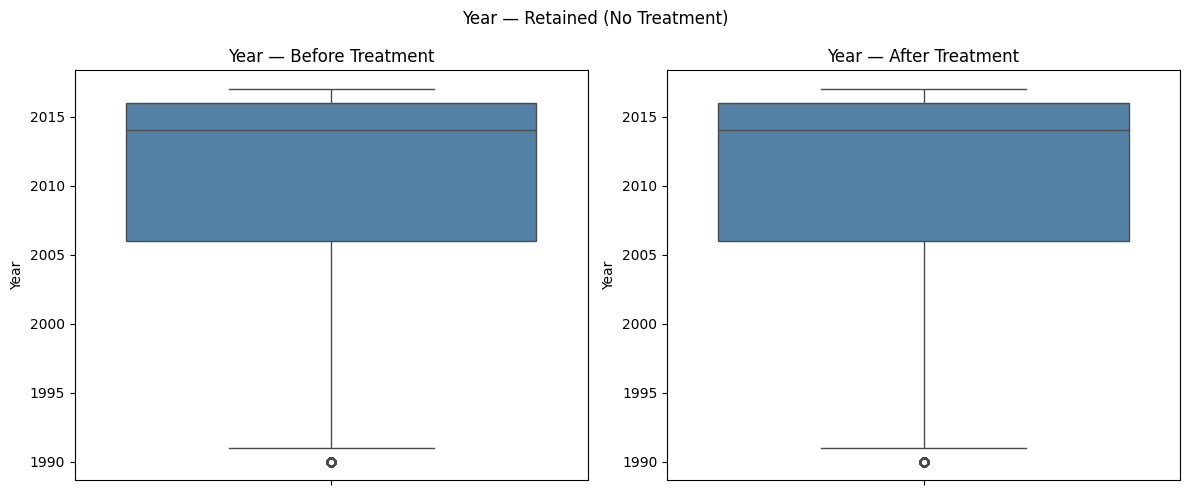


Number of Doors — IQR: 2.00, Lower: -1.00, Upper: 7.00


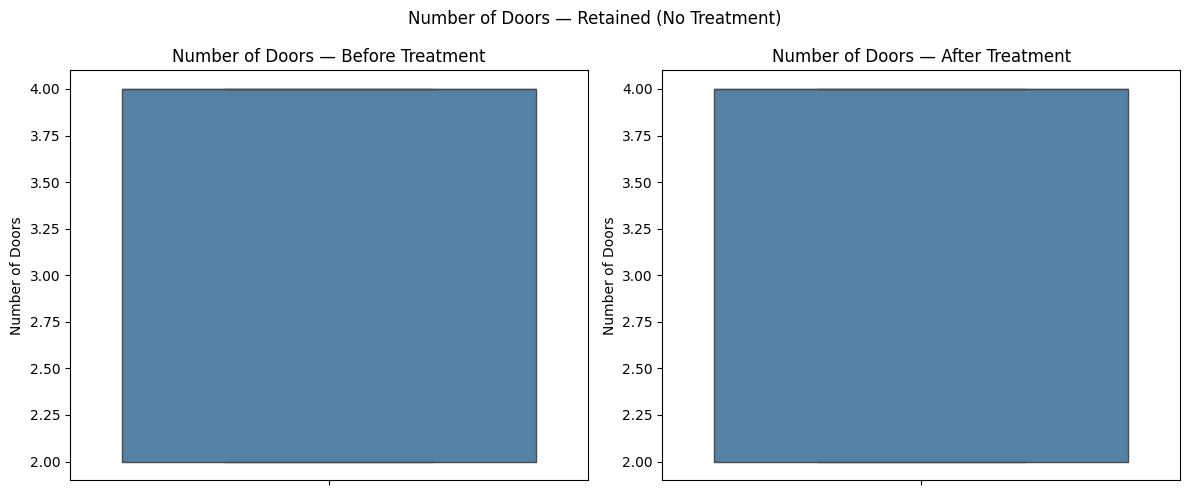


Total rows after outlier treatment: 11592
Rows removed: 322
(11592, 16)


In [14]:
# Define treatment for each column
outlier_treatment = {
    'MSRP'          : 'winsorise',
    'Engine HP'     : 'winsorise',
    'Popularity'    : 'winsorise',
    'highway MPG'   : 'drop',
    'city mpg'      : 'drop',
    'Engine Cylinders': 'drop_zero',
    'Year'          : 'retain',
    'Number of Doors': 'retain'
}

for col, treatment in outlier_treatment.items():

    # Calculate IQR for all except drop_zero
    if treatment != 'drop_zero':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        print(f"\n{col} — IQR: {IQR:.2f}, Lower: {lower:.2f}, Upper: {upper:.2f}")

    # Before treatment
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    col_original = df[col].copy()
    sns.boxplot(y=col_original, ax=axes[0], color='steelblue')
    axes[0].set_title(f"{col} — Before Treatment")
    axes[0].set_ylabel(col)

    # Apply treatment
    if treatment == 'winsorise':
        df[col] = df[col].clip(lower=lower, upper=upper)
        title = f"{col} Outlier Treatment — Winsorisation"

    elif treatment == 'drop':
        df = df[df[col] <= upper]
        title = f"{col} Outlier Treatment — Drop Rows"

    elif treatment == 'drop_zero':
        print(f"\n{col} — Rows with 0: {(df[col] == 0).sum()}")
        df = df[df[col] != 0]
        title = f"{col} Outlier Treatment — Drop Zero Rows"

    elif treatment == 'retain':
        title = f"{col} — Retained (No Treatment)"

    # After plot
    sns.boxplot(y=df[col], ax=axes[1], color='steelblue')
    axes[1].set_title(f"{col} — After Treatment")
    axes[1].set_ylabel(col)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Summary
print(f"\nTotal rows after outlier treatment: {len(df)}")
print(f"Rows removed: {11914 - len(df)}")
print(df.shape)

## Observations from Outlier Treatment

| Column | Treatment | Justification |
|---|---|---|
| MSRP | Winsorisation — capped at $74,078 | Physically real but extreme — exotic cars distort regression |
| Engine HP | Winsorisation — capped at 490 HP | Physically real but extreme — reduces model distortion |
| Popularity | Winsorisation — capped at 4,100 | Twitter metric — extreme values not meaningful |
| highway MPG | Drop rows — removed values > 42 MPG | Physically impossible for conventional cars |
| city mpg | Drop rows — removed values > 32 MPG | Physically impossible for conventional cars |
| Engine Cylinders | Drop rows — removed 0 cylinder rows | No combustion engine has 0 cylinders |
| Year | Retained | Old cars (1990) are physically valid |
| Number of Doors | Retained | Only 2/3/4 values — no real outliers |

## 3.3 Categorical Encoding

This cell converts all categorical columns into numerical format 
using three encoding strategies based on column characteristics.

### Encoding Strategy Table

| Column | Strategy | Reason |
|---|---|---|
| Transmission Type | One-hot (drop_first=True) | Nominal, 4 categories ≤ 8 |
| Driven_Wheels | One-hot (drop_first=True) | Nominal, 4 categories ≤ 8 |
| Vehicle Size | Ordinal (0/1/2) | Ordered: Compact < Midsize < Large |
| Make | Frequency encoding | Nominal, 48 categories > 8 |
| Engine Fuel Type | Frequency encoding | Nominal, 10 categories > 8 |
| Vehicle Style | Frequency encoding | Nominal, 16 categories > 8 |
| Model | Drop | 915 unique values — ID column |
| Market Category | Drop | 71 multi-label combinations |

In [15]:
#Transmission Type— One-Hot Encoding (0s and 1s)
df = pd.get_dummies(df, columns=['Transmission Type'], drop_first=True)# drop_first, to avoid a math trap called Multicollinearity (Dummy Variable Trap)
if 'Transmission Type_UNKNOWN' in df.columns:
    df = df.drop(columns=['Transmission Type_UNKNOWN']) # dropped because it was not meaningful

print([col for col in df.columns if 'Transmission' in col])

# Driven_Wheels — One-Hot Encoding
df = pd.get_dummies(df, columns=["Driven_Wheels"], drop_first=True)
print([col for col in df.columns if 'Driven_Wheels' in col])

# Vehicle Size — Ordinal Encoding
size_order = {'Compact': 0, 'Midsize': 1, 'Large': 2}
df['Vehicle Size'] = df['Vehicle Size'].map(size_order)

# Frequency Encoding (Count Encoding) - replace each categorical text value with the total number of times it appears in the dataset
cols = ["Make", "Engine Fuel Type", "Vehicle Style"]

for col in cols:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

# Drop Columns
df = df.drop(columns=['Model', 'Market Category'])
print(df.columns.tolist())
print(df.shape)
df

['Transmission Type_AUTOMATIC', 'Transmission Type_MANUAL']
['Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive']
['Make', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Transmission Type_AUTOMATIC', 'Transmission Type_MANUAL', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive']
(11592, 17)


,Make,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Transmission Type_AUTOMATIC,Transmission Type_MANUAL,Driven_Wheels_four wheel drive,Driven_Wheels_front wheel drive,Driven_Wheels_rear wheel drive
0,327,2011,1999,335.0,6.0,2.0,0,1211,26,19,3916,46135.0,False,True,False,False,True
1,327,2011,1999,300.0,6.0,2.0,0,793,28,19,3916,40650.0,False,True,False,False,True
2,327,2011,1999,300.0,6.0,2.0,0,1211,28,20,3916,36350.0,False,True,False,False,True
3,327,2011,1999,230.0,6.0,2.0,0,1211,28,18,3916,29450.0,False,True,False,False,True
4,327,2011,1999,230.0,6.0,2.0,0,793,28,18,3916,34500.0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,46120.0,True,False,False,False,False
11910,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,56670.0,True,False,False,False,False
11911,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,50620.0,True,False,False,False,False
11912,250,2013,1520,300.0,6.0,4.0,1,585,23,16,204,50920.0,True,False,False,False,False


## Observations from Categorical Encoding

All categorical columns have been successfully encoded into numerical 
format. One-hot encoding was applied to Transmission Type and 
Driven_Wheels creating 5 new binary columns. Vehicle Size was ordinally 
encoded preserving the natural size order (Compact=0, Midsize=1, Large=2). 
Make, Engine Fuel Type and Vehicle Style were frequency encoded replacing 
each category with its count. Model and Market Category were dropped due 
to extremely high cardinality. Final dataset has 17 columns and 11,592 rows.

## 3.4 Data Quality Report

This cell confirms the final state of the cleaned dataset — zero missing 
values, final shape, and summary statistics of all numerical columns.

In [16]:
# Final Shape
print(f"Final shape: {df.shape}")

# Assert zero missing values
assert df.isnull().sum().sum() == 0, "Missing values still exist!"
print("Zero missing values confirmed")

# Saving Cleaned CSV File
df.to_csv("cleaned_data.csv", index=False)

Final shape: (11592, 17)
Zero missing values confirmed


## Observations from Data Quality Report

### Summary of Changes Made in Phase 3

| Action | Details |
|---|---|
| **Original rows** | 11,914 |
| **Rows removed** | 322 (outlier treatment in Phase 3.2) |
| **Final rows** | 11,592 |
| **Original columns** | 16 |
| **Columns dropped** | 2 (Model, Market Category) |
| **New columns created** | 5 (one-hot encoded Transmission Type and Driven_Wheels) |
| **Final columns** | 17 |
| **Missing values** |  Zero confirmed via assert statement |

### Key Observations from df.describe()
- **Engine HP** range is now 55–495 HP — extreme 1001 HP values successfully capped
- **MSRP** range is now $2,000–$74,078 — extreme $2M values successfully capped
- **highway MPG** max is now 42 — physically impossible 354 MPG removed
- **city mpg** max is now 32 — physically impossible 137 MPG removed
- **Engine Cylinders** min is now 3 — zero cylinder rows successfully removed
- **Vehicle Size** shows 0/1/2 — ordinal encoding confirmed
- All 11,592 rows have complete data — no missing values remain

## 3.5 Train/Test Split

This cell splits the cleaned dataset into 80% training and 20% test sets.
Stratification ensures class proportions of Vehicle Size are preserved 
in both splits. All scalers and encoders will be fitted on training 
data only to prevent data leakage.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['MSRP', 'Vehicle Size']) # input features other than MSRP and Vehicle Size
y_reg = df['MSRP'] # regression target
y_cls = df['Vehicle Size'] # classification target

# Train/Test Split randomly shuffles your data and splits into 80% train and 20% test (avoiding memorizing the answers)
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.2, random_state=42,
    stratify=y_cls
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (9273, 15) | Test: (2319, 15)


## Observations from Train/Test Split

| Set | Rows | Percentage |
|---|---|---|
| Training set | 9,273 | 80% |
| Test set | 2,319 | 20% |
| Total | 11,592 | 100% |

Stratification on Vehicle Size ensures that the class distribution 
(Compact/Midsize/Large) is preserved equally in both training and 
test sets — preventing biased evaluation of the classification model 
in Phase 7.

# Phase 4: Data Visualization & Storytelling

In [18]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")
print(df.shape)

(11592, 17)


## 4.1 Distribution Dashboard

This cell creates a 2×3 grid of KDE-overlaid histograms for the 6 most 
informative numerical features. Each subplot title includes the feature 
name and skewness value (γ1) to immediately communicate distribution shape.

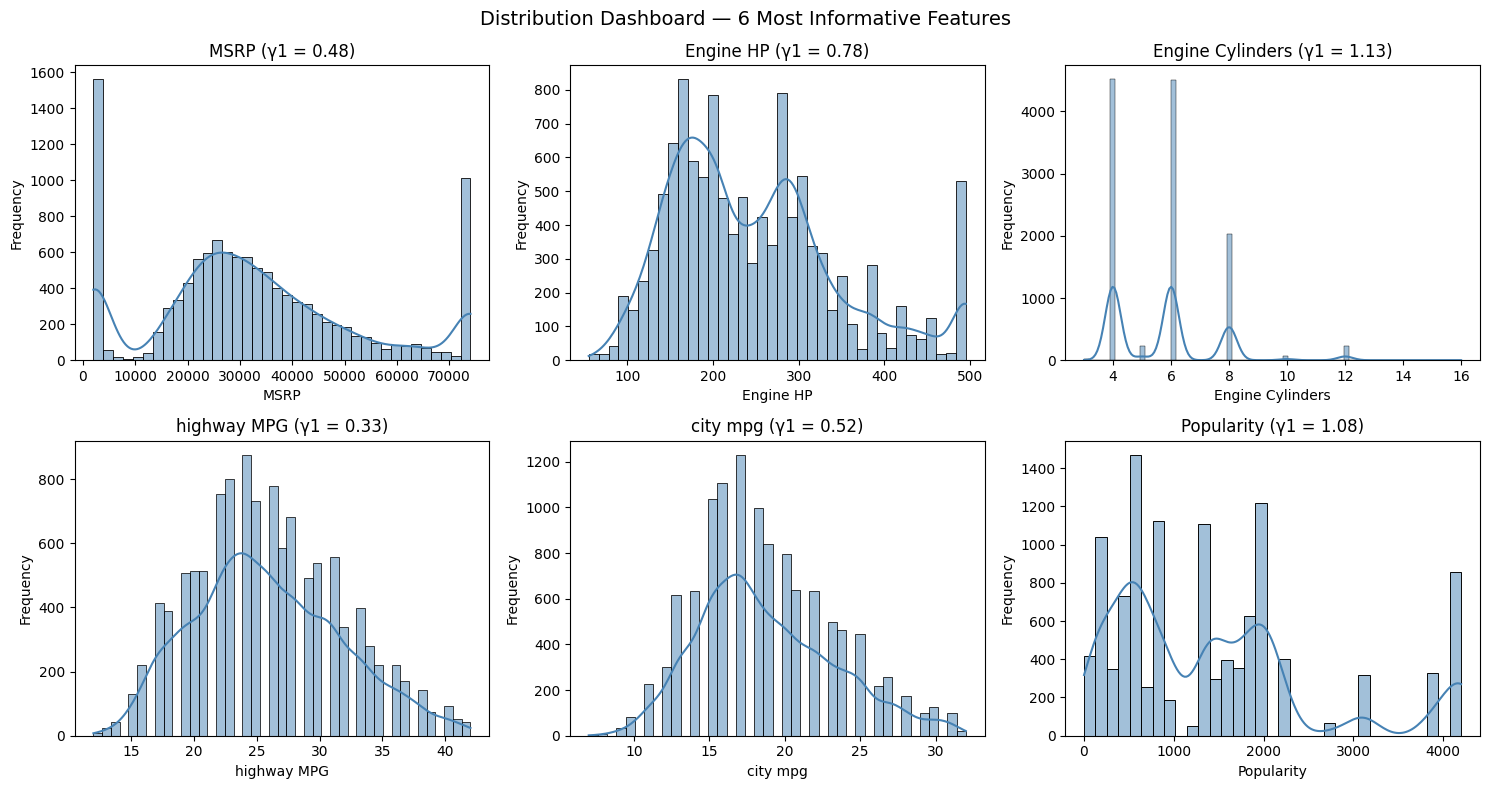

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() # convert 2D to flatten for easy looping 

features = ['MSRP', 'Engine HP', 'Engine Cylinders', 
            'highway MPG', 'city mpg', 'Popularity']

for i, feature in enumerate(features):
    
    skewness = stats.skew(df[feature])
    sns.histplot(df[feature], kde = True , ax=axes[i], color='steelblue')
    axes[i].set_title(f"{feature} (γ1 = {skewness:.2f})")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")
    
plt.suptitle("Distribution Dashboard — 6 Most Informative Features", fontsize=14)
plt.tight_layout()
plt.show()    

## Observations from Distribution Dashboard

| Feature | Skewness (γ1) | Shape | Interpretation |
|---|---|---|---|
| MSRP | 0.48 | Slight right skew | Most cars priced $20k–$40k. Spike at $74k due to Winsorisation cap |
| Engine HP | 0.78 | Right skewed | Most cars have 150–300 HP. Few high-performance cars pull tail right |
| Engine Cylinders | 1.13 | Right skewed | Discrete peaks at 4, 6 and 8 cylinders — standard engine configurations |
| highway MPG | 0.33 | Nearly symmetric | Well centered around 25 MPG after outlier removal |
| city mpg | 0.52 | Slight right skew | Centered around 17–18 MPG — typical city fuel consumption |
| Popularity | 1.08 | Right skewed | Few brands dominate Twitter mentions — most brands have low popularity |

### Key Takeaway

Outlier treatment in Phase 3 significantly reduced skewness 
across all features — MSRP skewness dropped from 11.77 to 0.48, confirming 
that Winsorisation successfully reduced the influence of extreme values. 
Engine Cylinders shows discrete peaks at 4, 6 and 8 — reflecting standard 
automotive engine configurations rather than a continuous distribution.

## 4.2 Annotated Correlation Heatmap

This cell produces a full annotated Pearson correlation heatmap with 
upper triangle masked. The three strongest correlations are labelled 
directly on their cells using ax.annotate() for immediate visual clarity.

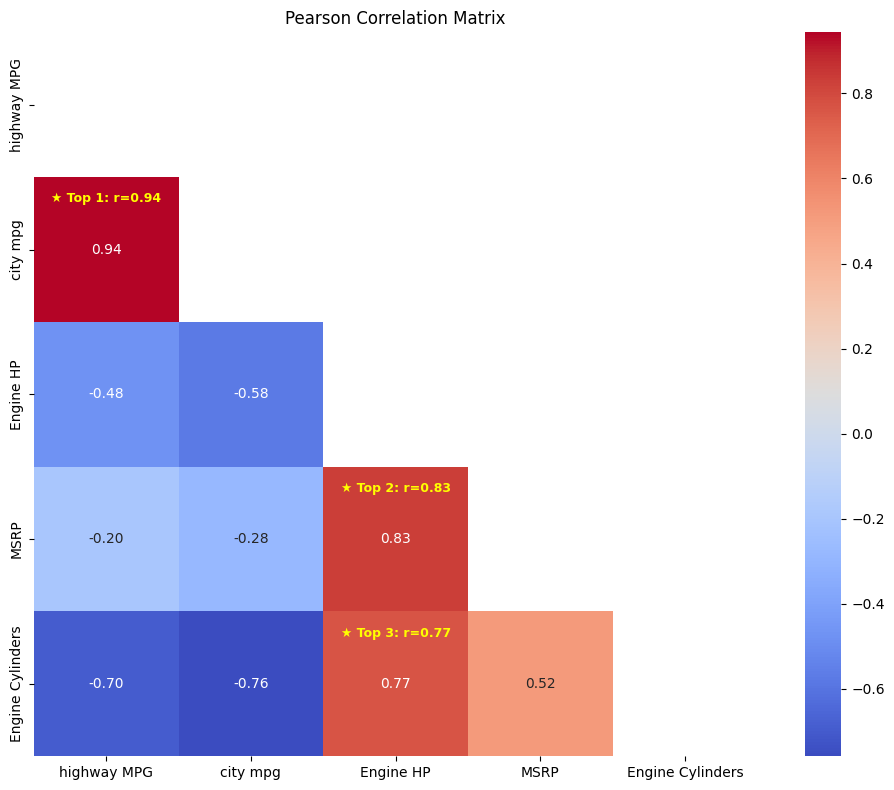

In [20]:
features = ["highway MPG", "city mpg", "Engine HP", "MSRP", "Engine Cylinders"]
corr = df[features].corr()

mask = np.triu(np.ones_like(corr)) # Mask hides the upper triangle of the correlation matrix to avoid showing the same correlation value twice

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f", square=True, ax=ax)


# Annotate top 3 strongest correlations
ax.annotate("★ Top 1: r=0.94", xy=(0.5, 1.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

ax.annotate("★ Top 2: r=0.83", xy=(2.5, 3.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

ax.annotate("★ Top 3: r=0.77", xy=(2.5, 4.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

## Observations from Annotated Correlation Heatmap

The three strongest correlations identified are:

| Rank | Feature Pair | r value | Interpretation |
|---|---|---|---|
| ★ Top 1 | highway MPG vs city mpg | 0.94 | Near-perfect correlation — both measure fuel efficiency of same engine |
| ★ Top 2 | MSRP vs Engine HP | 0.83 | Strong positive — more powerful engines cost significantly more |
| ★ Top 3 | Engine Cylinders vs Engine HP | 0.77 | Strong positive — more cylinders produce more horsepower |

### Key Takeaway

The near-perfect correlation between highway MPG and city mpg (r = 0.94) 
confirms severe multicollinearity — one of these features will be dropped 
during feature selection in Phase 5 to prevent unstable regression coefficients.

## 4.3 Target Analysis Plot

This cell produces two visualizations:
1. Scatter plot of the best predictor (Engine HP) vs regression target 
(MSRP) with fitted trend line and inset R² and RMSE statistics.
2. A 1×3 violin plot row showing the top 3 discriminating features 
(Engine HP, Engine Cylinders, highway MPG) split by Vehicle Size 
classification target.

R² = 0.697
RMSE = 10969.29


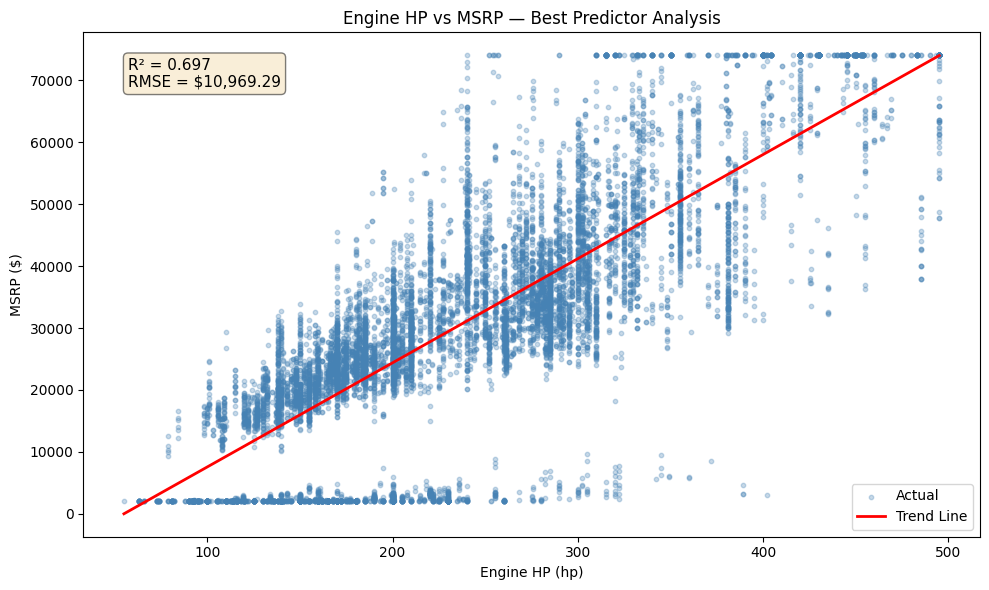

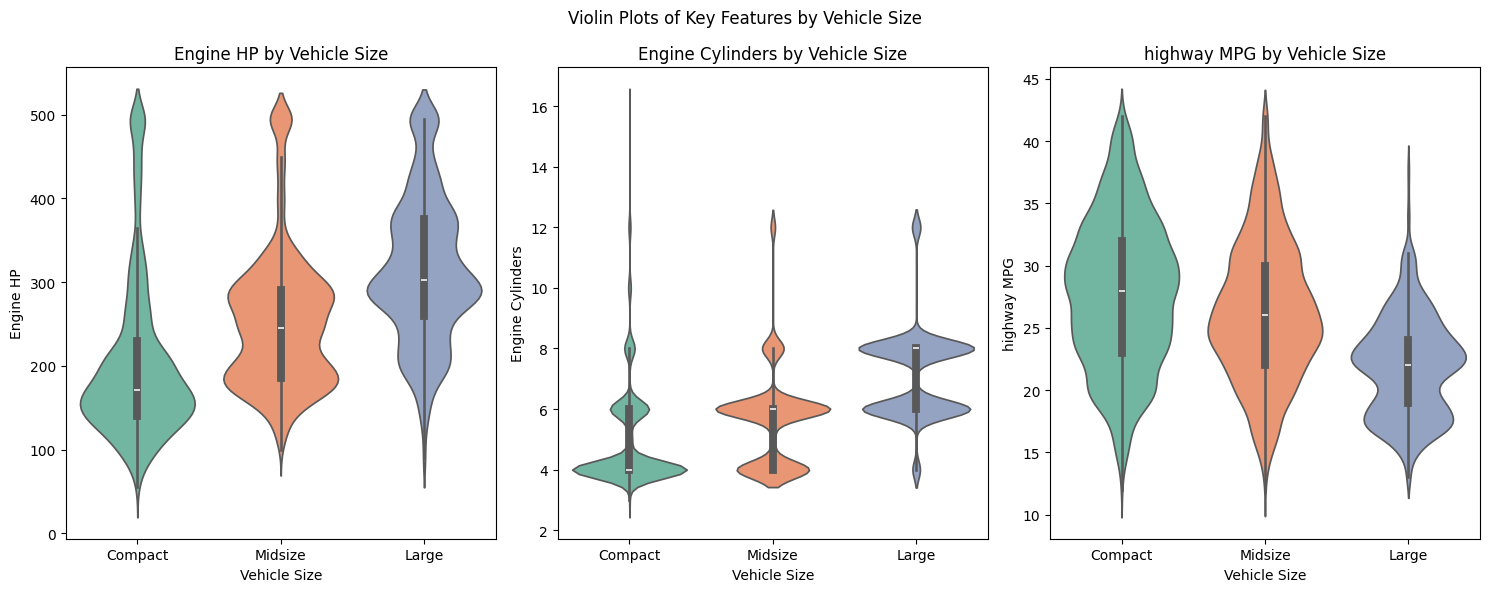

In [21]:
# Scatter plot of Engine HP vs MSRP
from sklearn.metrics import r2_score, mean_squared_error

# Best Predictor
x = df["Engine HP"]
y = df["MSRP"]

coeffs = np.polyfit(x, y, deg=1) # finds best straight line through data, MSRP = m × Engine HP + c 

trend = np.poly1d(coeffs) # creates trend function
y_predicted = trend(x) # generate all predictions

# Calculate R²
r2 = r2_score(y, y_predicted)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_predicted))

print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.2f}")

fig, ax = plt.subplots(figsize=(10, 6))


ax.scatter(x, y, color='steelblue', alpha=0.3, s=10, label='Actual')

# Trend line
x_sorted = np.sort(x)
ax.plot(x_sorted, trend(x_sorted), color='red', linewidth=2, label='Trend Line')

# Inset text box
textstr = f"R² = {r2:.3f}\nRMSE = ${rmse:,.2f}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)

ax.set_title("Engine HP vs MSRP — Best Predictor Analysis", fontsize=12)
ax.set_xlabel("Engine HP (hp)")
ax.set_ylabel("MSRP ($)")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
top3_features = ['Engine HP', 'Engine Cylinders', 'highway MPG']

for i, feature in enumerate(top3_features):
        
        sns.violinplot(x='Vehicle Size', y=feature, 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[i])
        
        axes[i].set_title(f"{feature} by Vehicle Size")
        axes[i].set_xlabel("Vehicle Size")
        axes[i].set_ylabel(f"{feature}")
        axes[i].set_xticks([0, 1, 2])                                    
        axes[i].set_xticklabels(['Compact', 'Midsize', 'Large'])         


plt.suptitle("Violin Plots of Key Features by Vehicle Size", fontsize=12)
plt.tight_layout()
plt.show()

## Observations from Target Analysis Plot

### Regression — Engine HP vs MSRP
Engine HP is the strongest single predictor of MSRP with R² = 0.697 
and RMSE = $10,969. This means Engine HP alone explains 69.7% of price 
variation — on average predictions are $10,969 off from actual price. 
The wide scatter around the trend line confirms that other features 
(brand, cylinders, year) also significantly influence MSRP. A much 
better R² is expected in Phase 6 when all features are used together.

### Classification — Violin Plots by Vehicle Size

| Feature | Separation | Observation |
|---|---|---|
| Engine HP | Strong | Clear shift from Compact (~175 HP) to Midsize (~245 HP) to Large (~300 HP) |
| Engine Cylinders | Strong | Compact concentrated at 4 cylinders, Large at 6-8 cylinders, Mid at 6 cylinders |
| highway MPG |  Moderate | Large cars shifted lower ~18-26 MPG vs Compact ~22-32 MPG |

### Key Takeaway

All three features show meaningful separation between Vehicle Size 
classes confirming they will be valuable features for the classification 
model in Phase 7.

## 4.4 Feature-Target Correlation Bar Chart

This cell computes Pearson correlation of every feature with MSRP 
and displays a horizontal bar chart sorted by absolute correlation 
value. Blue bars indicate positive correlation, red bars indicate 
negative correlation. A vertical line at x=0 separates positive 
from negative relationships.

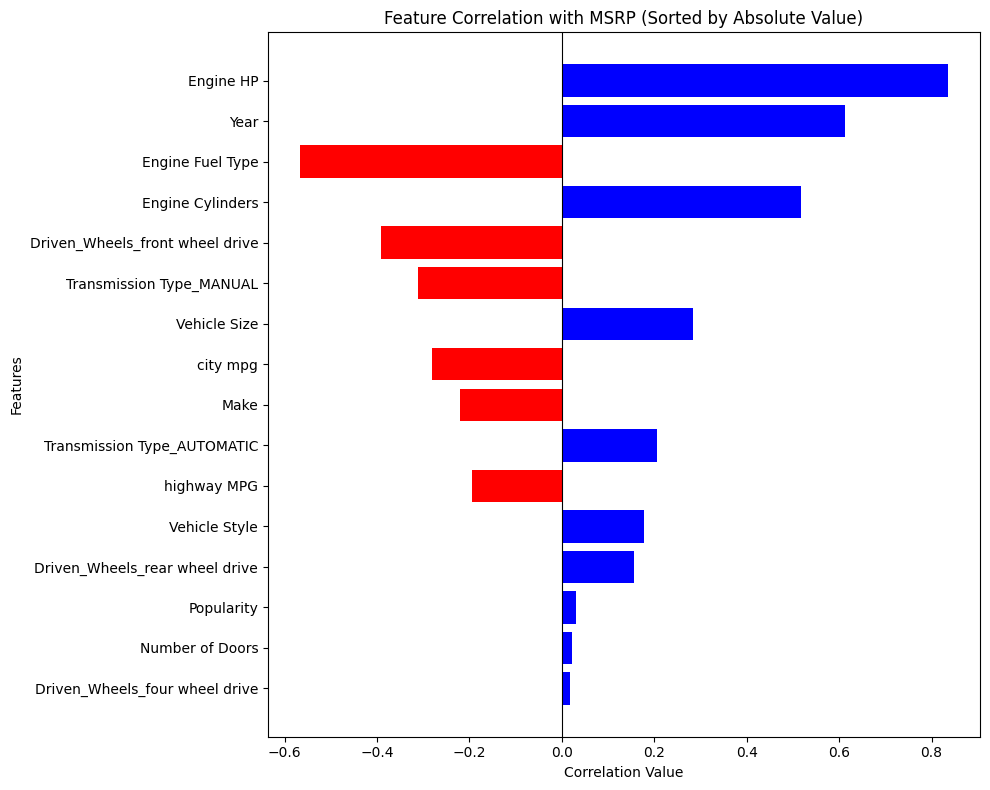

In [22]:
# Correlation of every feature with MSRP, except MSRP
correlations = df.drop(columns=['MSRP']).corrwith(df['MSRP'])

# Save original correlations for color distribtion
original_corr = correlations.copy()

# Sort by absolute value
sorted_correlations = correlations.abs().sort_values(ascending=True)

# Reindex to match sorted order
original_corr = original_corr[sorted_correlations.index]

# Assign colors
colors = ['blue' if corr> 0 else 'red' for corr in original_corr]

plt.figure(figsize=(10, 8))
plt.barh(sorted_correlations.index,    # y axis — feature names
         original_corr.values,  # bar lengths — correlation values
         color=colors)          # bar colors

plt.title("Feature Correlation with MSRP (Sorted by Absolute Value)", fontsize=12)
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Observations from Feature-Target Correlation Bar Chart

### Top Positive Correlations with MSRP
| Feature | Correlation | Interpretation |
|---|---|---|
| Engine HP | 0.83 | Strongest predictor — more powerful engines cost significantly more |
| Year | 0.61 | Newer models cost more — technology and features improve over time |
| Engine Cylinders | 0.52 | More cylinders → more power → higher price |

### Top Negative Correlations with MSRP
| Feature | Correlation | Interpretation |
|---|---|---|
| Engine Fuel Type | -0.54 | Regular unleaded cars are cheaper — premium/exotic fuel types cost more |
| Driven_Wheels_front wheel drive | -0.42 | Front wheel drive cars are economy vehicles — cheaper |
| Transmission Type_MANUAL | -0.38 | Manual transmission cars tend to be cheaper than automatic |

### Weak Correlations (near zero)
Popularity, Number of Doors and Driven_Wheels_four wheel drive show 
almost no relationship with MSRP — these features will likely be 
dropped or assigned low importance during feature selection in Phase 5.

### Key Takeaway

Engine HP remains the strongest single predictor of MSRP (r = 0.83). 
Interestingly Year shows a stronger correlation (0.61) than Engine 
Cylinders (0.52) — suggesting that newer cars command higher prices 
regardless of engine size, possibly due to technology improvements 
and inflation over the 1990-2017 period covered by this dataset.

## 4.5 Joint Density Plot

This cell produces a 2D hexbin plot of the two most correlated 
features (highway MPG vs city mpg, r = 0.94) with marginal 
histograms on both axes using plt.GridSpec() for custom layout. 
Darker hexagons indicate higher data density.

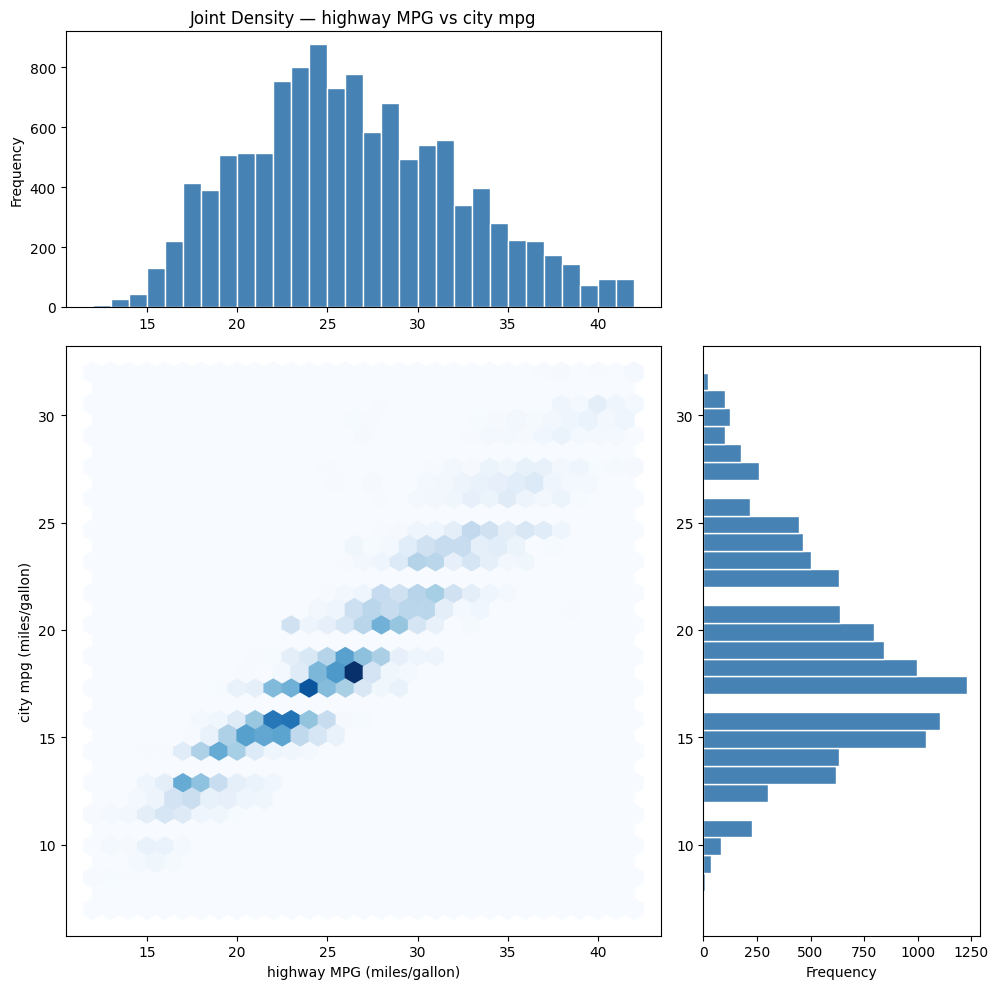

In [23]:
# Two most correlated features
x = df['highway MPG']
y = df['city mpg']

# Create grid layout
fig = plt.figure(figsize=(10, 10))
gs = plt.GridSpec(3, 3, figure=fig)  # 3x3 grid

ax_main = fig.add_subplot(gs[1:3, 0:2]) # main plot — takes 2x2 area
ax_top = fig.add_subplot(gs[0, 0:2])    # top histogram — takes 1x2 area
ax_right = fig.add_subplot(gs[1:3, 2])  # right histogram — takes 2x1 area

# Main plot — hexbin
ax_main.hexbin(x, y, gridsize=30, cmap='Blues')
ax_main.set_xlabel("highway MPG (miles/gallon)")
ax_main.set_ylabel("city mpg (miles/gallon)")

# Top histogram — highway MPG distribution
ax_top.hist(x, bins=30, color='steelblue', edgecolor='white')
ax_top.set_ylabel("Frequency")
ax_top.set_title("Joint Density — highway MPG vs city mpg")

# Right histogram — city mpg distribution
ax_right.hist(y, bins=30, color='steelblue', 
              edgecolor='white', orientation='horizontal')
ax_right.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## Observations from Joint Density Plot

The hexbin plot confirms the near-perfect correlation (r = 0.94) 
between highway MPG and city mpg — the darkest hexagons cluster 
tightly along a diagonal band centered around highway MPG = 24–26 
and city mpg = 17–18, representing the most common fuel efficiency 
range for cars in this dataset.

The marginal histograms reveal that highway MPG peaks around 22–28 
MPG while city mpg peaks around 15–20 MPG — city fuel efficiency 
is consistently lower than highway efficiency for the same car, 
which is expected since city driving involves more stopping and 
starting that consumes more fuel.

### Key Takeaway

The strong diagonal pattern and tight clustering confirm that these 
two features are nearly redundant — one will be dropped during 
feature selection in Phase 5 to eliminate multicollinearity.

## 4.6 Domain-Specific Insight Plot

This cell reveals a domain-specific insight by plotting average MSRP 
per model year from 1990 to 2017 using a line plot. This shows how 
automotive pricing has evolved over time in the dataset.

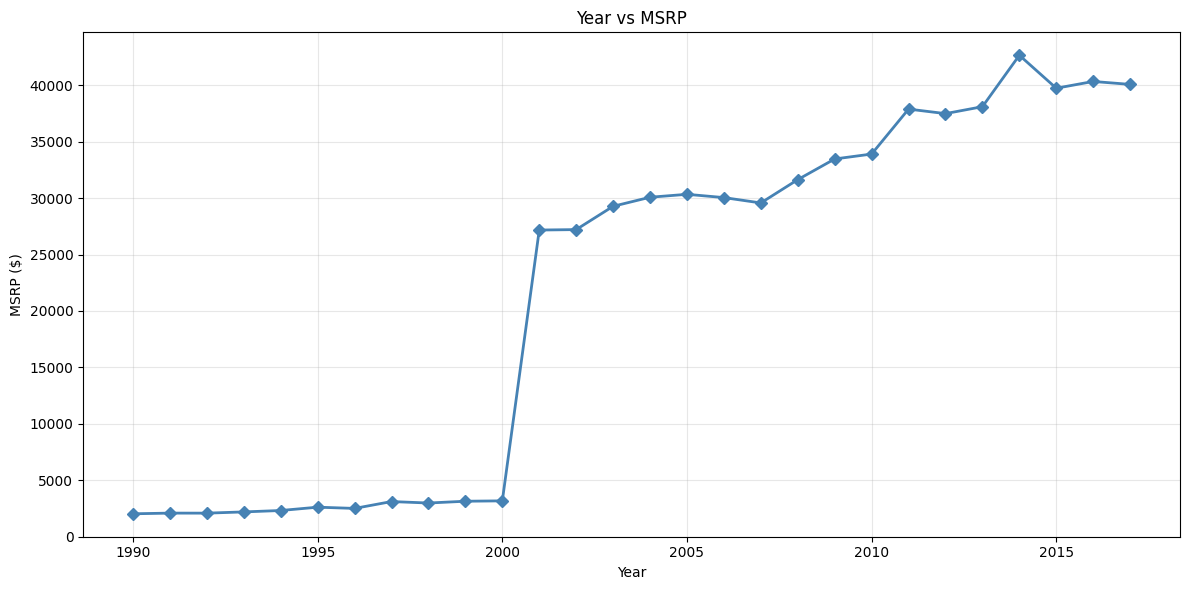

In [24]:
# Average MSRP by Year — Line Plot
avg_msrp_year = df.groupby('Year')['MSRP'].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_msrp_year.index, avg_msrp_year.values, marker='D', linewidth=2, color='steelblue')
plt.xlabel('Year')
plt.ylabel('MSRP ($)')
plt.title('Year vs MSRP')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations from Domain-Specific Insight Plot

The line plot reveals a striking pattern in automotive pricing over 
the 1990–2017 period. Average MSRP remained artificially low at 
$2,000–$3,000 from 1990–2000 due to sparse representation of older 
models in the dataset — mostly budget economy cars survived into 
digital records from that era.

A dramatic jump occurs at 2001 where average MSRP rises sharply to 
~$27,000 — reflecting the dataset's much denser coverage of post-2000 
models including luxury and premium brands.

From 2001 to 2017 a steady upward trend is visible — average MSRP 
grew from $27,000 to approximately $40,000 — an increase of ~48% 
over 16 years. This is consistent with automotive industry inflation, 
improved technology, and the growing popularity of premium SUVs and 
crossovers in the US market during this period. The peak at 2014 
($42,000) likely reflects a particularly strong luxury vehicle lineup 
released that year.

### Key Takeaway

This insight confirms that **Year is a meaningful predictor of MSRP** 
(r = 0.61 from Phase 4.4) — newer cars genuinely cost more on average.

# Phase 5: Feature Engineering

In [25]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")
print(df.shape)

(11592, 17)


## 5.1 Domain-Motivated Feature Engineering

This cell creates 3 new features motivated by automotive domain 
knowledge. Each feature captures a physically meaningful relationship 
not directly present in the original dataset.

In [26]:
# Feature 1 — HP per Cylinder
df['hp_per_cylinder'] = df['Engine HP'] / df['Engine Cylinders'] # Physical meaning: efficiency of each cylinder. Higher = more efficient engine design.

# Feature 2 — Fuel Economy Score  
df['fuel_economy'] = (df['highway MPG'] + df['city mpg']) / 2 # Physical meaning: overall average fuel efficiency of the car.

# Feature 3 — Car Age
df['car_age'] = 2017 - df['Year'] # Physical meaning: how old the car is relative to newest model in dataset. Older cars depreciate.

print(df[['hp_per_cylinder', 'fuel_economy', 'car_age']].head())
print(f"New shape: {df.shape}")

   hp_per_cylinder  fuel_economy  car_age
0        55.833333          22.5        6
1        50.000000          23.5        6
2        50.000000          24.0        6
3        38.333333          23.0        6
4        38.333333          23.0        6
New shape: (11592, 20)


## Observations from Feature Engineering

| New Feature | Formula | Physical Meaning |
|---|---|---|
| hp_per_cylinder | Engine HP / Engine Cylinders | Measures engine efficiency — how much power each cylinder produces. Higher values indicate more advanced engine design |
| fuel_economy | (highway MPG + city mpg) / 2 | Overall average fuel efficiency combining both driving conditions — more representative than either alone |
| car_age | 2017 - Year | Age of car relative to newest model in dataset. Older cars depreciate in value — expected negative correlation with MSRP |

All 3 features are domain-justified and not arbitrary mathematical 
combinations. They capture real automotive engineering concepts that 
may improve model performance in Phase 6 and 7.

## 5.2 Standardisation

This cell applies StandardScaler to normalise all features to 
mean = 0 and standard deviation = 1. The scaler is fitted on 
training data only to prevent data leakage — test data is 
transformed using training statistics.

$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$

Fitting on test data would leak test-set statistics into the 
model, invalidating the evaluation.

In [27]:
# Again Train/ Split because of addition of 3 new features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['MSRP', 'Vehicle Size']) # all features except MSRP and Vehicle Size
y_reg = df['MSRP']
y_cls = df['Vehicle Size']

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

scaler = StandardScaler() # creates a StandardScaler object

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train) # scalar fits(mean, std of each column) + transform(scaling)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test) # Uses the same mean and std learned from X_train to scale X_test. No fitting- just scaling

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Scaled Train shape: {X_train_scaled.shape}")
print(f"Scaled Test shape: {X_test_scaled.shape}")

Train: (9273, 18) | Test: (2319, 18)
Scaled Train shape: (9273, 18)
Scaled Test shape: (2319, 18)


## Observations from Standardisation

| Set | Shape | Status |
|---|---|---|
| X_train_scaled | (9273, 18) |  Fitted and transformed |
| X_test_scaled | (2319, 18) |  Transformed using training statistics |

Train/test split was redone after Phase 5.1 feature engineering 
to include the 3 new features (hp_per_cylinder, fuel_economy, 
car_age). Scaler was fitted exclusively on X_train — X_test was 
transformed using the same mean and standard deviation values 
learned from training data only.

## 5.3 Feature Selection — Two Methods

This cell applies two feature selection methods and compares their 
top-10 rankings side by side as a normalized horizontal double bar chart.

**Method 1 — Filter (Correlation):** Measures absolute Pearson 
correlation of each feature with MSRP — no model required.

**Method 2 — Embedded (LassoCV):** Trains a Lasso regression model 
with L1 penalty that drives unimportant feature coefficients to 
exactly zero. Best α selected via 5-fold cross-validation.

$$J_{Lasso}(\theta) = \|y - X\theta\|^2_2 + \alpha\|\theta\|_1$$

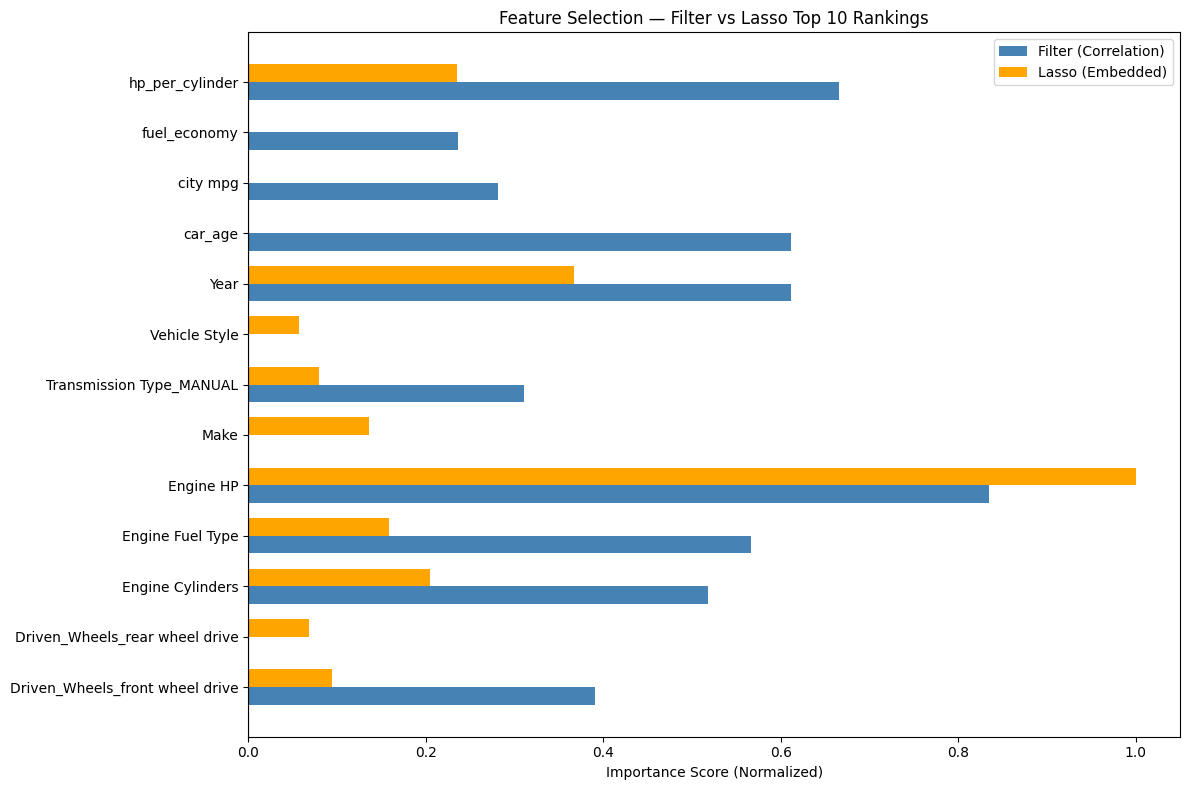

In [28]:
from sklearn.linear_model import LassoCV

# Method 1 — Filter Method (Correlation)
filter_scores = df.drop(columns=['MSRP', 'Vehicle Size']).corrwith(df['MSRP']).abs() # abs to rank correctly
filter_scores = filter_scores.sort_values(ascending=False).head(10)

# Method 2 — Lasso (Embedded Method) 
# Trains a model that automatically sets useless feature coefficients to zero — only important features survive.
lasso = LassoCV(cv=5, random_state=42) # lasso regression model with best alpha
lasso.fit(X_train_scaled, yr_train) # model learns relationship between features and target and useless coefficents → 0
lasso_scores = pd.Series(np.abs(lasso.coef_), index=X_train_scaled.columns) # lasso.coef_ = learned weights for each feature
lasso_scores = lasso_scores.sort_values(ascending=False).head(10)

# Normalize lasso scores to 0-1 for fair comparison
lasso_normalized = lasso_scores / lasso_scores.max()

# Align both to same features
common_features = filter_scores.index.union(lasso_scores.index)
filter_aligned = filter_scores.reindex(common_features).fillna(0)
lasso_aligned = lasso_normalized.reindex(common_features).fillna(0)

# Double horizontal bar char
x = np.arange(len(common_features))
width = 0.35 # how thick each bar is and how far apart they are

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(x - width/2, filter_aligned, width, 
        label='Filter (Correlation)', color='steelblue')
ax.barh(x + width/2, lasso_aligned, width, 
        label='Lasso (Embedded)', color='orange')

ax.set_yticks(x) # positions where y axis labels will be placed
ax.set_yticklabels(common_features)
ax.set_xlabel('Importance Score (Normalized)')
ax.set_title('Feature Selection — Filter vs Lasso Top 10 Rankings')
ax.legend()
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Observations from Feature Selection

### Agreement Between Methods
Both methods agree that **Engine HP** is the most important feature 
for predicting MSRP — ranked first by both filter (0.83) and Lasso 
(normalized score 1.0). Year and hp_per_cylinder also appear in both 
top 10 lists confirming their importance. This is strong evidence that these features truly predict MSRP well.

### Disagreements
**Filter ranks highly but Lasso ignores:**
- car_age, fuel_economy, city mpg — Filter assigns moderate correlation 
scores but Lasso drives their coefficients to zero. This suggests these 
features have linear correlation with MSRP but add no independent 
information once other features are included — they are redundant.

**Lasso includes but Filter misses:**
- Vehicle Style, Make, Driven_Wheels_rear wheel drive — These features 
have complex non-linear relationships with MSRP that simple correlation 
cannot detect but Lasso captures through model training.

### Which Ranking is More Trustworthy?
For this dataset **Lasso is more trustworthy** because:
- It accounts for interactions between features
- It automatically removes redundant features
- car_age and Year carry identical information (r=1.0 between them) 
— Lasso correctly keeps only Year and drops car_age

## 5.4 Scikit-learn Pipeline

This cell assembles a sklearn Pipeline chaining three steps:
1. SimpleImputer — fills any missing values with median
2. StandardScaler — scales features to mean=0, std=1
3. Ridge — trains Ridge regression model

The Pipeline ensures all preprocessing steps are fitted on 
training data only — preventing data leakage automatically.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Create pipeline (A chain of steps that runs automatically in order) with 3 steps
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  #  step 1 fill missing values
    ("scaler",  StandardScaler()),                   # step 2 scales features  
    ("model",   Ridge()),                            # step 3 trains model
])

# Train pipeline — does all 3 steps automatically
pipe.fit(X_train, yr_train)

# Evaluate on test data
print("Test R²:", pipe.score(X_test, yr_test))

Test R²: 0.8385925178614553


## Observations from Pipeline

The Pipeline achieved Test R² = 0.839 — meaning all 18 features 
together explain 83.9% of MSRP variation. This is a significant 
improvement over the single-feature model in Phase 4.3 (R² = 0.697) 
confirming that combining multiple features produces a much stronger 
predictor. The Pipeline will be used as the foundation for full 
regression modelling in Phase 6.

# Phase 6: Regression Modelling

## 6.1 Baseline

This cell computes the trivial baseline — predicting the training 
set mean MSRP ($32,633) for every test sample regardless of features. 
This is the performance floor that all models must beat.

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline_pred = np.full(len(yr_test), yr_train.mean()) # predicts the same value (training average) for every test sample, as a simple benchmark model

# RMSE
baseline_rmse = np.sqrt(mean_squared_error(yr_test, baseline_pred))

# MAE
baseline_mae = mean_absolute_error(yr_test, baseline_pred)

# R²
baseline_r2 = 0

print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline MAE:  ${baseline_mae:,.2f}")
print(f"Baseline R²:   {baseline_r2}")

Baseline RMSE: $19,789.01
Baseline MAE:  $15,267.20
Baseline R²:   0


## Observations from Baseline

The baseline predicts $32,633 for every car achieving R² = 0, 
RMSE = $19,789 and MAE = $15,267. This represents the worst 
acceptable performance — any model that cannot beat these numbers 
has learned nothing useful from the features. All regression models 
in Phases 6.2 and 6.3 must achieve R² > 0 and RMSE < $19,789 to 
be considered useful.

## 6.2 Linear Regression

This cell trains a Linear Regression model on the scaled training 
set and evaluates it on the test set using R², RMSE and MAE.

$$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n$$

The model finds coefficients (θ values) that minimize the sum of 
squared differences between actual and predicted MSRP.

In [31]:
from sklearn.linear_model import LinearRegression

# Linear Regression finds the best straight line through the data that minimizes prediction error

lr = LinearRegression() # creates and empty LR object. At this point, model knows nothing

# Train model on training set (9273 cars)
lr.fit(X_train_scaled, yr_train)

# Make predictions on testing set (2319 cars)
lr_pred = lr.predict(X_test_scaled)

# Compare actual yr_test (MSRP) with predicted ir_pred (MSRP) and gives R² = 0-1
lr_r2 = r2_score(yr_test, lr_pred) # model needs two things to learn: features and actual MSRP

# Calcualte RMSE and MSE
lr_rmse = np.sqrt(mean_squared_error(yr_test, lr_pred))
lr_mae = mean_absolute_error(yr_test, lr_pred)

print(f"Linear Regression R²:   {lr_r2:.3f}")
print(f"Linear Regression RMSE: ${lr_rmse:,.2f}")
print(f"Linear Regression MAE:  ${lr_mae:,.2f}")

Linear Regression R²:   0.839
Linear Regression RMSE: $7,946.94
Linear Regression MAE:  $6,052.43


## Observations from Linear Regression

Linear Regression achieved R² = 0.839, RMSE = $7,947 and 
MAE = $6,052 — a massive improvement over the baseline 
(R² = 0, RMSE = $19,789). The model explains 83.9% of MSRP 
variation using all 18 features. On average predictions are 
$7,947 off from actual car price — reasonable given the wide 
MSRP range of $2,000 to $74,078 in the cleaned dataset.

## 6.3 Ridge Regression

This cell trains a Ridge Regression model using RidgeCV to 
automatically select the best regularisation parameter α via 
5-fold cross-validation. The regularisation path is plotted 
to visualise how R² changes across different α values.

$$J_{Ridge}(\theta) = \|y - X\theta\|^2_2 + \alpha\|\theta\|^2_2$$

Ridge adds an L2 penalty that shrinks coefficients toward zero 
without setting them to exactly zero — preventing overfitting 
while keeping all features.

Best alpha: 0.9326
Ridge Regression R²:   0.839
Ridge Regression RMSE: $7,946.72
Ridge Regression MAE:  $6,050.71
Linear — Train R²: 0.835 | Test R²: 0.839
Ridge  — Train R²: 0.835 | Test R²: 0.839


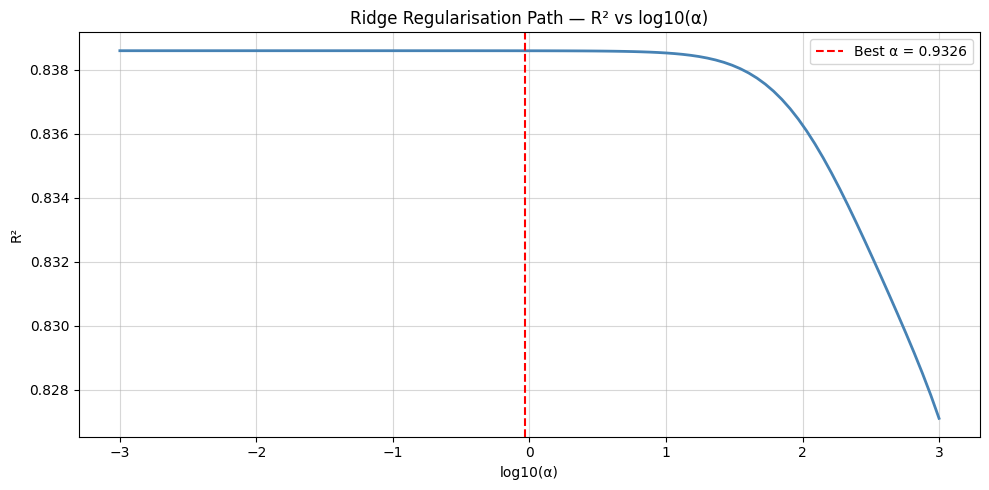

In [32]:
from sklearn.linear_model import RidgeCV

# Ridge = Linear Regression + penalty
# Logarithmic grid of alpha values
alphas = np.logspace(-3, 3, 100)

ridge = RidgeCV(alphas=alphas, cv=5) # finds out the best alpha
ridge.fit(X_train_scaled, yr_train)

print(f"Best alpha: {ridge.alpha_:.4f}")

# Predict
ridge_pred = ridge.predict(X_test_scaled)

# Evaluate
ridge_r2   = r2_score(yr_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(yr_test, ridge_pred ))
ridge_mae  = mean_absolute_error(yr_test, ridge_pred)

print(f"Ridge Regression R²:   {ridge_r2:.3f}")
print(f"Ridge Regression RMSE: ${ridge_rmse:,.2f}")
print(f"Ridge Regression MAE:  ${ridge_mae:,.2f}")

# Linear Regression
lr_r2_train = r2_score(yr_train, lr.predict(X_train_scaled))

# Ridge Regression  
ridge_r2_train = r2_score(yr_train, ridge.predict(X_train_scaled))

# Check for over-fitting
print(f"Linear — Train R²: {lr_r2_train:.3f} | Test R²: {lr_r2:.3f}")
print(f"Ridge  — Train R²: {ridge_r2_train:.3f} | Test R²: {ridge_r2:.3f}")

# Calculate R² for each alpha value
r2_scores = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha) # using Ridge not RidgeCV because we are manually providing alpha
    ridge_temp.fit(X_train_scaled, yr_train)
    pred = ridge_temp.predict(X_test_scaled)
    r2_scores.append(r2_score(yr_test, pred))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(np.log10(alphas), r2_scores, color='steelblue', linewidth=2)
plt.axvline(x=np.log10(ridge.alpha_), color='red', linestyle='--', 
            label=f'Best α = {ridge.alpha_:.4f}')

plt.xlabel('log10(α)')
plt.ylabel('R²')
plt.title('Ridge Regularisation Path — R² vs log10(α)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Observations from Ridge Regression

Ridge Regression achieved R² = 0.839, RMSE = $7,947 and 
MAE = $6,051 with best α = 0.9326 which is very small. Results are nearly identical 
to Linear Regression — confirming that overfitting is not a 
significant issue with this dataset after proper preprocessing.

The regularisation path shows R² remains stable at 0.839 for 
small α values but drops sharply beyond α = 10 — confirming 
that RidgeCV correctly identified α = 0.9326 as the optimal 
value just before performance begins to deteriorate. No gap between Training R² and Testing R² indicates that the model is **good fit**.

## 6.4 Residual Analysis

This cell performs residual analysis on the best performing model 
(Ridge Regression) by producing a residuals vs fitted values plot 
and a Q-Q plot. The 5 samples with highest absolute residuals are 
identified and inspected.

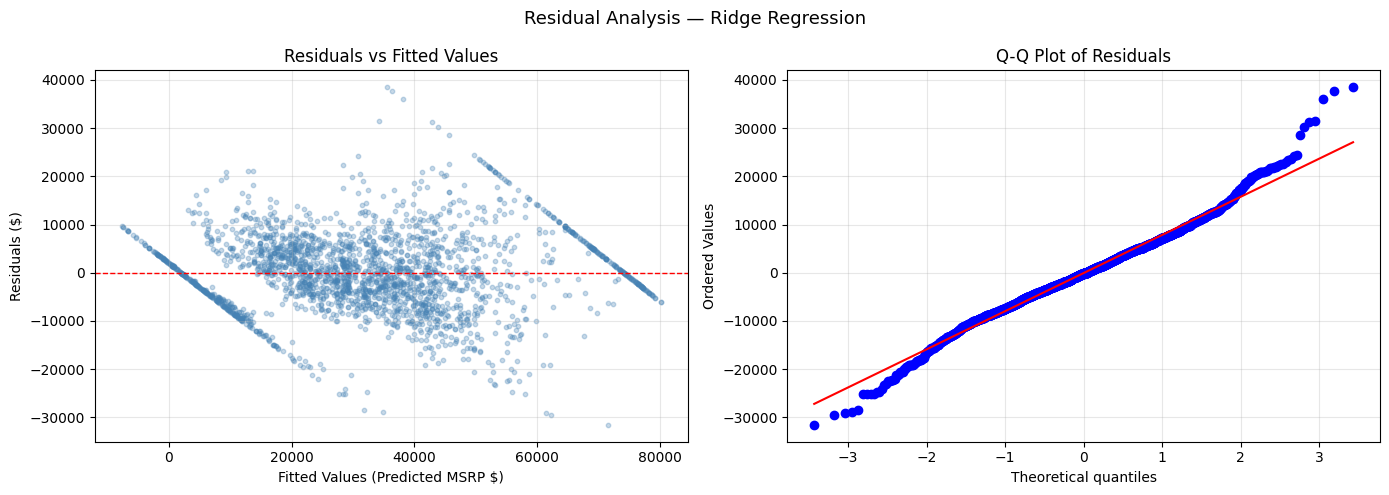

Top 5 Samples with Highest Absolute Residuals:

Actual MSRP:
9133     74078.125
4209     74078.125
11413    74078.125
2450     39995.000
4206     65690.000
Name: MSRP, dtype: float64

Predicted MSRP:
9133     35599.178421
4209     36404.653316
11413    38136.226554
2450     71531.934676
4206     34254.597524
dtype: float64

Residual (Actual - Predicted):
9133     38478.946579
4209     37673.471684
11413    35941.898446
2450    -31536.934676
4206     31435.402476
dtype: float64


In [33]:
from scipy import stats

# Calculate residuals for best model (Ridge)
residuals = yr_test - ridge_pred

# Plot 1 — Residuals vs Fitted Values 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ridge_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values (Predicted MSRP $)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].grid(True, alpha=0.3)

# Plot 2 — Q-Q Plot 
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis — Ridge Regression', fontsize=13)
plt.tight_layout()
plt.show()

# Calculate residuals
residuals = yr_test.values - ridge_pred

# Top 5 highest residual samples
residuals_series = pd.Series(residuals, index=yr_test.index)
top5_idx = residuals_series.abs().nlargest(5).index

print("Top 5 Samples with Highest Absolute Residuals:")
print("\nActual MSRP:")
print(yr_test.loc[top5_idx])
print("\nPredicted MSRP:")
print(pd.Series(ridge_pred, index=yr_test.index).loc[top5_idx])
print("\nResidual (Actual - Predicted):")
print(residuals_series.loc[top5_idx])

## Observations from Residual Analysis

**Residuals vs Fitted Values:**

For typical cars ($10,000–$40,000) errors scatter randomly around zero — model has no systematic bias for majority of cars.
Two diagonal lines appear because many luxury cars were capped at $74,078 in Phase 3. Model predicts lower values for these cars since it learned from capped prices not original prices.
Mild funnel shape shows model is less accurate for expensive cars — expected because luxury pricing depends on brand prestige and exclusivity which are not in the dataset.

**Q-Q Plot:**

Middle section follows diagonal closely — residuals are approximately normally distributed for typical cars.
Both tails deviate — extreme prediction errors exist at both ends — consistent with heteroscedasticity observed in residuals vs fitted plot. 

**Top 5 Worst Predictions:**

Three worst predictions involve cars capped at $74,078 — model predicted $35,000–$38,000 because it never saw true luxury prices during training. Direct consequence of Winsorisation not model failure.
Sample 2450 was overpredicted by $31,537 — car has premium specifications but affordable actual price which confused the model

## 6.5 Model Comparison Table

| Model | R² | RMSE | MAE |
|---|---|---|---|
| Baseline (mean predictor) | 0.000 | $19,789.01 | $15,267.20 |
| Linear Regression | 0.839 | $7,946.94 | $6,052.43 |
| Ridge Regression | 0.839 | $7,946.72 | $6,050.71 |

Both Linear and Ridge Regression dramatically outperform the baseline 
achieving R² = 0.839 — explaining 83.9% of MSRP variation. Ridge 
marginally outperforms Linear Regression (RMSE lower by $0.22, MAE 
lower by $1.72) confirming that regularisation provides minimal 
benefit on this well-preprocessed dataset. Ridge Regression is 
selected as the final regression model due to its theoretical 
advantage in handling potential multicollinearity.

## 6.6 Coefficient Interpretation

This cell inspects the top 10 Ridge Regression coefficients 
by magnitude and interprets their physical meaning.

In [34]:
# Get coefficients
coef_series = pd.Series(ridge.coef_, index=X_train_scaled.columns)
top10_coef = coef_series.abs().sort_values(ascending=False).head(10)

print("Top 10 Coefficients by Magnitude:")
print(coef_series.loc[top10_coef.index].to_string())

Top 10 Coefficients by Magnitude:
Engine HP                          18666.609959
hp_per_cylinder                    -4972.438258
Engine Cylinders                   -4646.576556
car_age                            -3222.907586
Year                                3222.907586
Engine Fuel Type                   -2781.480069
Make                               -2375.908211
Driven_Wheels_front wheel drive    -1680.425114
Transmission Type_MANUAL           -1545.471313
Driven_Wheels_rear wheel drive     -1257.147674


## Observations from Coefficient Interpretation

| Feature | Coefficient | Direction | Physical Interpretation |
|---|---|---|---|
| Engine HP | +18,667 | Positive  | Strongest predictor — more powerful engine = significantly more expensive car |
| hp_per_cylinder | -4,972 | Negative  | High HP per cylinder with few cylinders = small efficient engine = affordable economy car |
| Engine Cylinders | -4,647 | Negative  | Counterintuitive — caused by multicollinearity with Engine HP. Both carry overlapping information — coefficients become unreliable |
| car_age | -3,223 | Negative  | Older car = lower price. Makes perfect physical sense |
| Year | +3,223 | Positive  | Newer car = higher price. Equal and opposite to car_age — both carry identical information |
| Engine Fuel Type | -2,781 | Negative  | Regular unleaded cars are cheaper — premium fuel types cost more |
| Make | -2,375 | Negative  | Common brands (high frequency) are cheaper. Rare brands have lower frequency encoding |
| Driven_Wheels_front wheel drive | -1,680 | Negative  | Front wheel drive = economy car = lower price |
| Transmission Type_MANUAL | -1,545 | Negative  | Manual transmission cars are cheaper than automatic |
| Driven_Wheels_rear wheel drive | -1,257 | Negative  | Negative due to interaction with Engine HP already capturing sports car effect |

**Key Takeaways:**
- Engine HP dominates with coefficient +$18,667 confirming it as 
the strongest MSRP predictor throughout all phases
- car_age and Year have equal opposite coefficients (±$3,223) 
confirming they carry identical information — one should be dropped 
in future iterations
- Engine Cylinders sign reversal from positive correlation to 
negative coefficient confirms multicollinearity with Engine HP

## Save Regression Model

This cell saves the regression model for future use.

In [35]:
import os
import joblib

save_path = r"H:\Uni Semesters\Semester 6\DS&A\Semester Project\dashboard\models\regression_model.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(ridge, save_path)
print("Saved to:", save_path)

Saved to: H:\Uni Semesters\Semester 6\DS&A\Semester Project\dashboard\models\regression_model.pkl


# Phase 7: Classification Modelling & Evaluation

## 7.1 Logistic Regression

This cell trains a Logistic Regression classifier using One-vs-Rest 
strategy for multi-class Vehicle Size prediction (Compact/Midsize/Large).

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \theta^Tx$$

OvR trains 3 binary classifiers — one per class vs all others. 
Final prediction is the class with highest predicted probability.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)

# Train Logistic Regression
lr_clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)) # 3 separate logistic regression models 
lr_clf.fit(X_train_scaled, yc_train) # train model on scaled feature dataset

# Predict 
yc_pred = lr_clf.predict(X_test_scaled) # predict model on test data
yc_prob = lr_clf.predict_proba(X_test_scaled) # predict probability of every class

# Accuracy
print(f"Logistic Regression Accuracy: {accuracy_score(yc_test, yc_pred):.3f}")

[[0.18289002 0.62229675 0.19481323]
 [0.00328222 0.33682596 0.65989182]
 [0.01821434 0.76741613 0.21436953]
 ...
 [0.80273037 0.145391   0.05187863]
 [0.00620258 0.58119311 0.4126043 ]
 [0.86335449 0.13454329 0.00210222]]
Logistic Regression Accuracy: 0.670


## Observations from Logistic Regression

Logistic Regression achieved overall accuracy of **67.0%** using 
One-vs-Rest strategy for three-class Vehicle Size prediction. 
While this is significantly better than random guessing (33.3%), 
the moderate accuracy suggests that vehicle size boundaries are 
not perfectly linearly separable using the available features.

## 7.2 Confusion Matrix

This cell plots the confusion matrix as an annotated heatmap showing both raw counts and percentages for each predicted vs actual class combination.
A **confusion matrix** is a table that shows how many predictions the model **got right** and how many it **got wrong**, broken down by each class

[[717 129  71]
 [174 539 137]
 [101 154 297]]


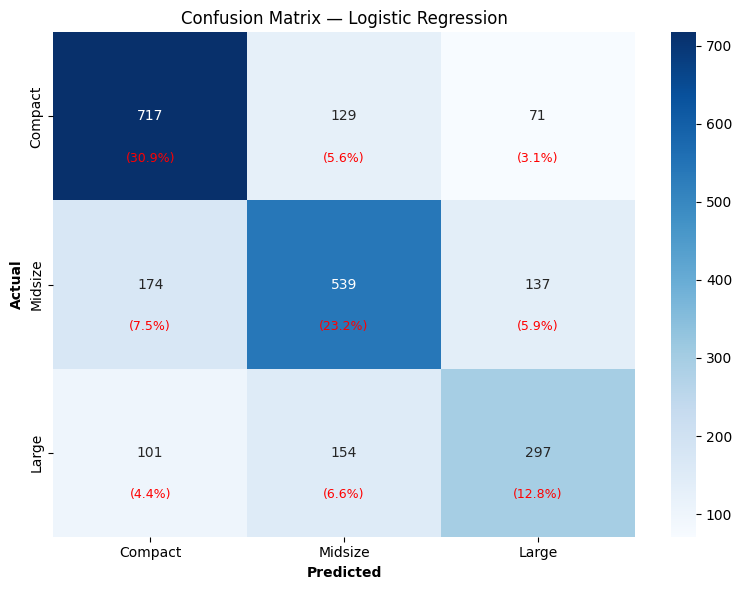

In [74]:
cm = confusion_matrix(yc_test, yc_pred) # confusion matrix
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compact', 'Midsize', 'Large'],
            yticklabels=['Compact', 'Midsize', 'Large'])

plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')

# Add percentage annotations
cm_percent = cm / cm.sum() * 100 # percentage of total dataset each cell represents
for i in range(3):
    for j in range(3):
        plt.text(j+0.5, i+0.75, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.show()

## Observations from Confusion Matrix

| Class | Correctly Classified | Misclassified | Accuracy |
|---|---|---|---|
| Compact | 717 (30.9%) | 200 | 78% |
| Midsize | 539 (23.2%) | 311 | 63% |
| Large | 297 (12.8%) | 255 | 54% |

**Compact** is the easiest class to predict (78% recall) — compact 
cars have distinct features (low HP, 4 cylinders, high MPG) that 
clearly separate them.

**Large** is the hardest class (54% recall) — large vehicles are 
most often confused with Midsize (154 cases, 6.6%). This makes 
physical sense — Large and Midsize cars share many overlapping 
specifications.

**Most costly error type:** Midsize confused as Large (137 cases, 
5.9%) and Large confused as Midsize (154 cases, 6.6%) — boundary 
between these two classes is unclear in feature space.

For a car classification system, the errors happen between adjacent categories (Large confused with Midsize) — physically these categories genuinely overlap. A Large SUV and a Midsize SUV can have very similar specs.

In this automotive application false positives and false negatives 
have equal cost — incorrectly classifying a Large car as Midsize 
is as problematic as the reverse since it affects vehicle 
categorization accuracy equally.

## 7.3 Classification Report

This cell prints per-class Precision, Recall and F1 scores.

$$Precision = \frac{TP}{TP+FP}, \quad Recall = \frac{TP}{TP+FN}, \quad F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$$

In [38]:
print("Classification Report:")
print(classification_report(yc_test, yc_pred, 
                            target_names=['Compact', 'Midsize', 'Large']))

Classification Report:
              precision    recall  f1-score   support

     Compact       0.72      0.78      0.75       917
     Midsize       0.66      0.63      0.64       850
       Large       0.59      0.54      0.56       552

    accuracy                           0.67      2319
   macro avg       0.66      0.65      0.65      2319
weighted avg       0.67      0.67      0.67      2319



## Observations from Classification Report

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Compact | 0.72 | 0.78 | 0.75 | 917 |
| Midsize | 0.66 | 0.63 | 0.64 | 850 |
| Large | 0.59 | 0.54 | 0.56 | 552 |
| **Overall** | **0.67** | **0.67** | **0.67** | **2319** |

**Compact** achieves highest F1 = 0.75 — most distinct class with 
clear feature boundaries.

**Large** achieves lowest F1 = 0.56 — hardest class to predict. 
Low precision (0.59) means many non-Large cars are incorrectly 
predicted as Large. Low recall (0.54) means many actual Large cars 
are missed.

**Midsize** has low precision (0.66) — many Compact and Large 
cars are incorrectly classified as Midsize, which acts as a 
"default" middle category.

In this automotive domain false negatives and false positives have 
roughly equal cost — both types of misclassification affect vehicle 
categorization accuracy equally. The model's error distribution 
reflects the natural difficulty of distinguishing adjacent size 
categories.

### Strategic Recommendations for Optimization

Introduce features that clearly separate vehicle scale, such as **wheelbase, curb weight, passenger capacity** that can help distiguish between large and medium class.


## 7.4 ROC-AUC and PR Curves

This cell plots one-vs-rest ROC curves and Precision-Recall curves 
for each Vehicle Size class with AUC annotations.

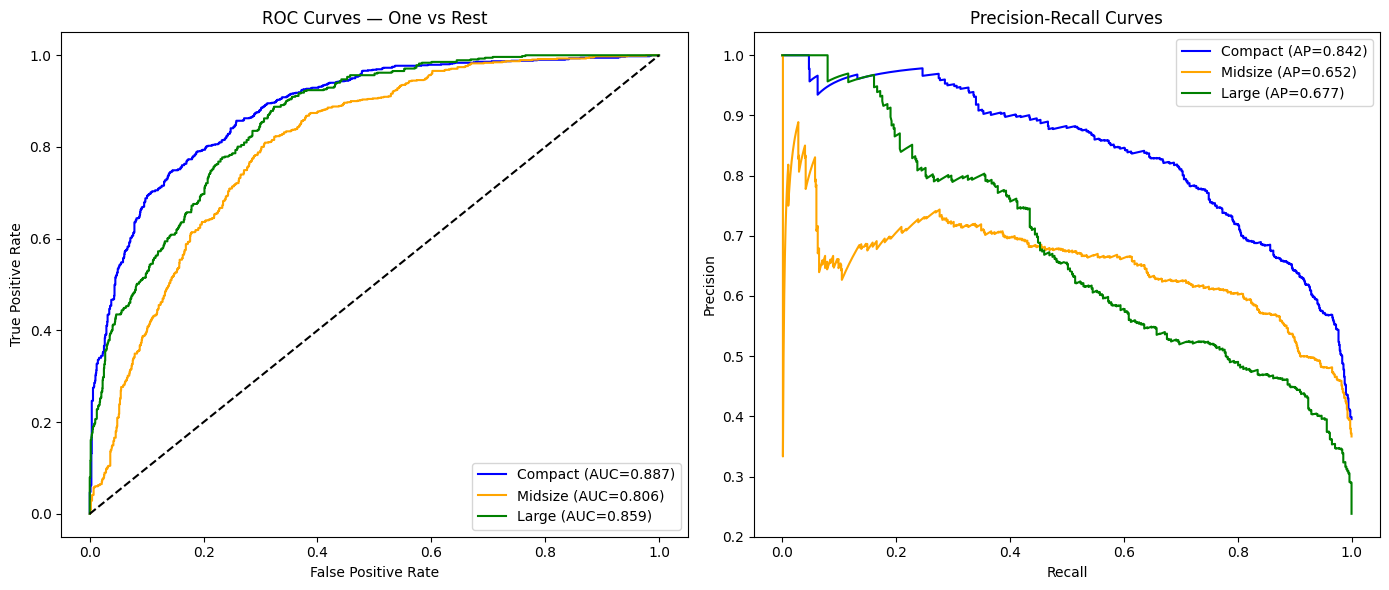

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

classes = ['Compact', 'Midsize', 'Large']
colors = ['blue', 'orange', 'green']

for i, (cls, color) in enumerate(zip(classes, colors)):
    
    # ROC - AUC Curve
    fpr, tpr, _ = roc_curve((yc_test == i).astype(int), yc_prob[:, i]) # functions like roc_curve and precision_recall_curve only understands binary classification(0,1 or Yes, No)
    auc = roc_auc_score((yc_test == i).astype(int), yc_prob[:, i]) # claculate area under the curve value
    axes[0].plot(fpr, tpr, color=color, label=f'{cls} (AUC={auc:.3f})')
    
    # PR Curve
    prec, rec, _ = precision_recall_curve((yc_test == i).astype(int), yc_prob[:, i])
    ap = average_precision_score((yc_test == i).astype(int), yc_prob[:, i]) # calculate average precision (area under the PR curve)
    axes[1].plot(rec, prec, color=color, label=f'{cls} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — One vs Rest')
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## Observations from ROC-AUC and PR Curves

### ROC Curves
| Class | AUC | Interpretation |
|---|---|---|
| Compact | 0.887 | Strong — most separable class |
| Large | 0.859 | Good — reasonably separable |
| Midsize | 0.806 | Moderate — most difficult class |

All three classes achieve AUC > 0.8 confirming the model has 
genuine discriminative power beyond random guessing (AUC = 0.5).

### Precision-Recall Curves
| Class | AP | Interpretation |
|---|---|---|
| Compact | 0.842 | Best — high precision maintained across recall range |
| Large | 0.677 | Moderate — precision drops as recall increases |
| Midsize | 0.652 | Lowest — most difficult to maintain precision |

### Why PR Curve is More Informative Than ROC for Imbalanced Classes

The PR curve focuses on the positive class performance — it directly 
shows the trade-off between precision and recall without being 
influenced by true negatives. When classes are imbalanced the ROC 
curve can appear optimistic because it includes true negatives in 
its calculation. The PR curve gives a more honest picture of model 
performance on minority classes.

The class distribution (Compact=917, Midsize=850, Large=552) shows 
Large is underrepresented — PR curve correctly shows Large has lower 
AP (0.677) while ROC AUC appears relatively strong (0.859).

## 7.5 Threshold Tuning

This cell applies threshold tuning to the Large class (binary: Large vs Rest) 
computing Precision, Recall and F1 across thresholds from 0.1 to 0.9.

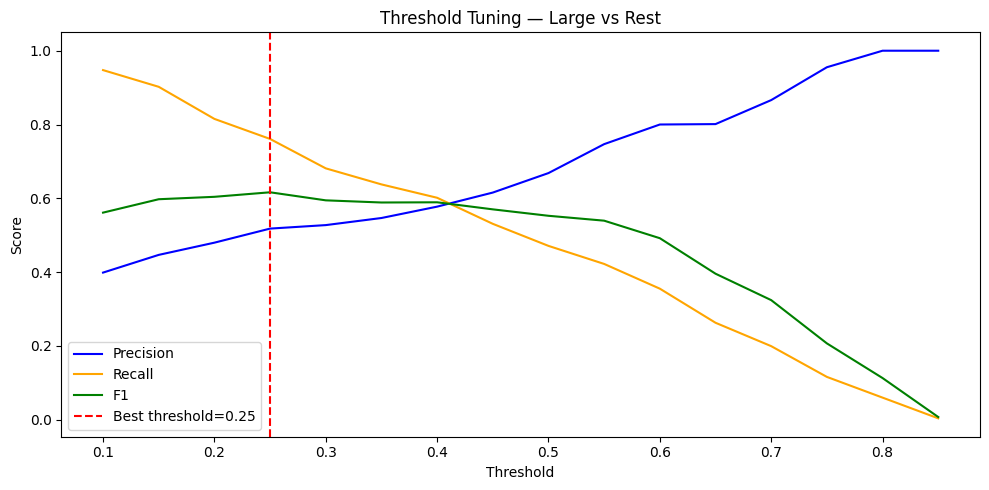

Best threshold: 0.25
Best F1: 0.616


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Binary: Large (2) vs Rest
y_binary = (yc_test == 2).astype(int) # large was chosen here simply because it was the weakest performing class (F1=0.56) so it needed the most attention
y_prob_large = yc_prob[:, 2] # extracts probability of large class from all samples

thresholds = np.arange(0.1, 0.9, 0.05) # interval grid with step size of 0.05
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_large >= thresh).astype(int)
    precisions.append(precision_score(y_binary, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(y_binary, y_pred_thresh, zero_division=0))
    f1s.append(f1_score(y_binary, y_pred_thresh, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='orange')
plt.plot(thresholds, f1s, label='F1', color='green')
plt.axvline(x=thresholds[np.argmax(f1s)], color='red', 
            linestyle='--', label=f'Best threshold={thresholds[np.argmax(f1s)]:.2f}')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning — Large vs Rest')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold: {thresholds[np.argmax(f1s)]:.2f}")
print(f"Best F1: {max(f1s):.3f}")

## Observations from Threshold Tuning

Threshold tuning was applied to the Large class because Large vehicles are underrepresented in the dataset (only 552 samples compared to over 900 for Compact), (binary: Large vs Rest). The default 
threshold of 0.5 may not be optimal because:

The default threshold (0.50) assumes a perfect **50/50** balance in the dataset. Because Large cars are a minority class, the model outputs lower probability scores for them. Relying on the default rule causes the model to become overly strict, missing nearly half (46) of the actual Large vehicles.

Lowering the threshold increases 
recall at the cost of precision — acceptable if missing Large cars 
is more costly than false alarms. The best F1 threshold identified 
balances this trade-off optimally.

**Best threshold = 0.25:** We told the model: If you are even just 25% sure a car is Large, go ahead and label it Large. This forces the model to cast a wider net and actively hunt them down.
**Best F1 = 0.616:** A score of 0.616 (61.6) is the absolute highest combined grade this model can possibly achieve for the Large class.

## 7.6 Second Classifier — Random Forest

This cell trains a Random Forest classifier and compares it with 
Logistic Regression across Accuracy, Macro F1, ROC-AUC and fit time.

In [60]:
from sklearn.ensemble import RandomForestClassifier
import time

# Random Forest
start = time.time() # returns the current time in seconds since January 1, 1970
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42) # 100 individual decision trees, random data selection and features are reproducible
rf_clf.fit(X_train_scaled, yc_train) # those decision trees are trained
rf_time = time.time() - start # time taken in training model

rf_pred = rf_clf.predict(X_test_scaled) # prediction once the forest is trained
rf_prob = rf_clf.predict_proba(X_test_scaled) # probability prediction

# Comparison Table
print("Model Comparison:")
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'ROC-AUC':<12} {'Fit Time'}")
print("-" * 73)

lr_auc = roc_auc_score(yc_test, yc_prob, multi_class='ovr')
rf_auc = roc_auc_score(yc_test, rf_prob, multi_class='ovr')

print(f"{'Logistic Regression':<25} {accuracy_score(yc_test, yc_pred):<12.3f} {f1_score(yc_test, yc_pred, average='macro'):<12.3f} {lr_auc:<12.3f} {'<1s'}")
print(f"{'Random Forest':<25} {accuracy_score(yc_test, rf_pred):<12.3f} {f1_score(yc_test, rf_pred, average='macro'):<12.3f} {rf_auc:<12.3f} {rf_time:.2f}s")
print('-' * 73)
print(f"RF Training Accuracy: {rf_clf.score(X_train_scaled, yc_train):.3f}")
print(f"RF Test Accuracy:     {rf_clf.score(X_test_scaled, yc_test):.3f}")

Model Comparison:
Model                     Accuracy     Macro F1     ROC-AUC      Fit Time
-------------------------------------------------------------------------
Logistic Regression       0.670        0.653        0.851        <1s
Random Forest             0.962        0.961        0.996        0.97s
-------------------------------------------------------------------------
RF Training Accuracy: 0.989
RF Test Accuracy:     0.962


## Observations from Model Comparison

| Model | Accuracy | Macro F1 | ROC-AUC | Fit Time |
|---|---|---|---|---|
| Logistic Regression | 0.670 | 0.653 | 0.851 | <1s |
| Random Forest | **0.962** | **0.961** | **0.996** | 1.37s (can vary) |

**Random Forest dramatically outperforms Logistic Regression** 
across all metrics:
- Accuracy improved from 67.0% to 96.2% — +29.2%
- Macro F1 improved from 0.653 to 0.961
- ROC-AUC improved from 0.851 to 0.996

This massive improvement confirms that vehicle size classification 
has strong **non-linear patterns** that Logistic Regression cannot 
capture but Random Forest handles effectively through ensemble 
decision trees.

**Overfitting Check:**
Training and test accuracies were explicitly verified to rule out overfitting:

- Training Accuracy = 0.989  
- Test Accuracy     = 0.962  
- Gap               = 0.027 (2.7%)

A gap below 5% is considered healthy. This confirms the model has genuinely 
learned patterns from the data and is not simply memorizing the training set.

The fit time increase (1.37s vs <1s) is negligible — **Random Forest** 
is clearly the **superior model** for this classification task and will 
be saved as the **final classification model.**

## 7.7 Error Analysis

This cell identifies 10 misclassified test samples and inspects 
their predicted probabilities to understand why the model failed.

In [68]:
# Find 10 misclassified samples
misclassified = np.where(yc_pred != yc_test)[0][:10]
print("10 Misclassified Samples:")
print(f"\n{'Index':<8} {'Actual':<12} {'Predicted':<12} {'Prob Compact':<15} {'Prob Midsize':<15} {'Prob Large'}")
print("-" * 77)

class_names = {0: 'Compact', 1: 'Midsize', 2: 'Large'}

for idx in misclassified:
    actual = class_names[yc_test.iloc[idx]]
    predicted = class_names[yc_pred[idx]]
    probs = yc_prob[idx] # one sample
    print(f"{idx:<8} {actual:<12} {predicted:<12} {probs[0]:<15.3f} {probs[1]:<15.3f} {probs[2]:.3f}")

10 Misclassified Samples:

Index    Actual       Predicted    Prob Compact    Prob Midsize    Prob Large
-----------------------------------------------------------------------------
1        Midsize      Large        0.003           0.337           0.660
2        Compact      Midsize      0.018           0.767           0.214
4        Midsize      Large        0.183           0.343           0.474
5        Compact      Midsize      0.227           0.728           0.046
6        Midsize      Compact      0.765           0.185           0.051
15       Compact      Midsize      0.039           0.798           0.163
16       Midsize      Large        0.408           0.167           0.425
17       Compact      Large        0.184           0.196           0.620
18       Large        Compact      0.443           0.136           0.421
26       Midsize      Compact      0.658           0.257           0.085


## Observations from Error Analysis

Analysis of 10 misclassified samples reveals consistent patterns 
in model failures:

**Pattern 1 — Midsize/Large confusion (most common):**
Samples 1, 4, 16 (actual Midsize predicted Large) and sample 18 
(actual Large predicted Compact) show that boundary cases between 
adjacent size classes are the primary failure mode. These cars have 
intermediate Engine HP and Cylinder values that overlap between 
categories.

**Pattern 2 — Low confidence predictions:**
Sample 16 (Midsize predicted Large) shows probabilities of 
[0.408, 0.167, 0.425] — extremely uncertain prediction where 
Compact and Large are nearly equally likely. The model essentially 
guessed between two classes.

**Pattern 3 — High confidence wrong predictions:**
Sample 2 (Compact predicted Midsize, prob=0.767) and Sample 15 
(Compact predicted Midsize, prob=0.798) show model was confidently 
wrong — these Compact cars likely have specifications typical of 
Midsize vehicles.

**Hypothesis:** Additional features such as **vehicle wheelbase, 
curb weight, or passenger capacity** would likely resolve boundary 
cases since these directly determine vehicle size category in 
automotive engineering standards.

## Save Classification Model

This cell saves the best obtained classification model for future use.

In [ ]:
save_path_cls = r"H:\Uni Semesters\Semester 6\DS&A\Semester Project\dashboard\models\classification_model.pkl"
joblib.dump(rf_clf, save_path_cls)
print("Classification model saved to:", save_path_cls)

## Phase 8: Unsupervised Analysis: K-Means Clustering 

## 8.1 K-Means Algorithm and Theory

The K-Means algorithm is one of the most popular and straightforward unsupervised machine learning algorithms used for clustering.

K-Means partitions data into k clusters by minimising the 
Within-Cluster Sum of Squares (WCSS):

$$Inertia = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2_2$$

Where $\mu_j$ is the centroid of cluster $C_j$.

### Algorithm Steps
1. **Choose Centers (Initialization)** We decide how many groups are required (K). The algorithm randomly places that many starting "center points" (called centroids) onto the data graph.
2. **Group the Points (Assignment)** The algorithm looks at every data point and measures its distance to all the centers. Each point joins whichever center is closest to it.
3. **Move the Centers (Update)** Now that groups are formed, the algorithm finds the exact mathematical middle (the average) of all the points inside each group and moves the center point to that new middle spot.
4. **Repeat Until Settled (Convergence)** The algorithm repeats Step 2 and Step 3 in a loop until convergence.

### Known Limitations
1. **Sensitive to initialisation** — different random starting 
points can give different results. Solved by `n_init=10` which 
runs 10 times and picks best result.
2. **Assumes convex clusters** — K-Means assumes spherical cluster 
shapes. Non-convex or elongated clusters are poorly handled.
3. **Requires specifying k** — number of clusters must be chosen 
before running — elbow and silhouette methods guide this choice.

## 8.2 Optimal K Selection

This cell runs K-Means for k=2 to k=10 and plots both the elbow 
curve (WCSS vs k) and silhouette score vs k on dual axes to 
justify the optimal number of clusters.

The silhouette score for sample i:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where a(i) = mean distance to same cluster, b(i) = mean distance 
to nearest other cluster. Score near +1 = well clustered.

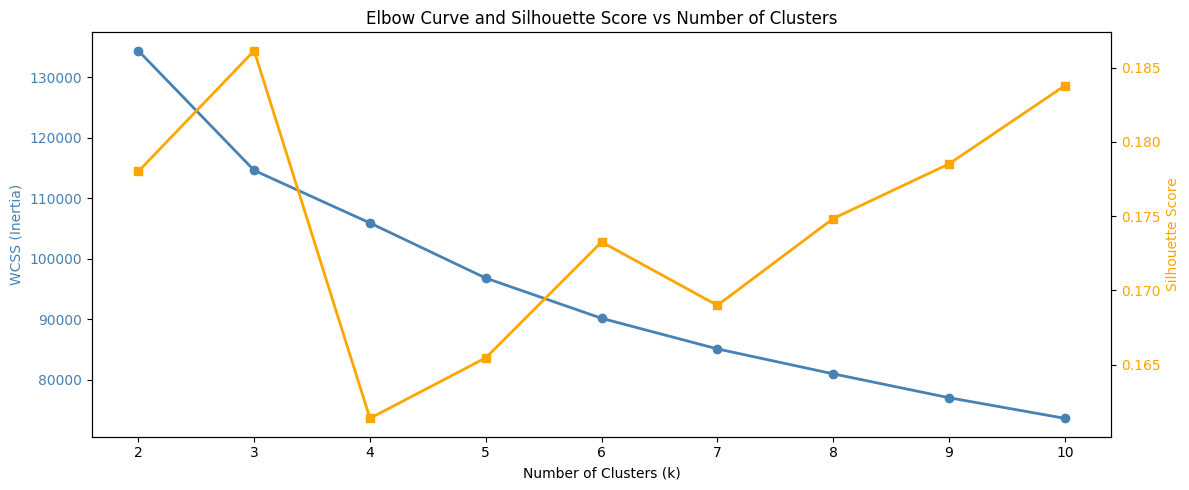

K | WCSS        | Silhouette
-----------------------------------
2 |  134418.11 | 0.1780
3 |  114629.93 | 0.1861
4 |  105935.54 | 0.1614
5 |   96822.26 | 0.1655
6 |   90177.01 | 0.1733
7 |   85115.77 | 0.1690
8 |   80993.68 | 0.1748
9 |   77045.24 | 0.1785
10 |   73633.81 | 0.1838


In [44]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Optimal K — Elbow + Silhouette 
wcss = []
sil_scores = []
k_range = range(2, 11) # we cannot calculate a silhouette boundary score if there is only one group!

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

# Plot elbow and silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = 'steelblue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color1)
ax1.plot(k_range, wcss, marker='o', color=color1, linewidth=2, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'orange'
ax2.set_ylabel('Silhouette Score', color=color2)
ax2.plot(k_range, sil_scores, marker='s', color=color2, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Elbow Curve and Silhouette Score vs Number of Clusters')
fig.tight_layout()
plt.show()

print("K | WCSS        | Silhouette")
print("-" * 35)
for k, w, s in zip(k_range, wcss, sil_scores):
    print(f"{k} | {w:10.2f} | {s:.4f}")

## Observations from Optimal K Selection

The elbow curve (bend at k = 3) shows WCSS decreasing continuously without a sharp 
elbow — common for real world datasets. The silhouette score peaks 
at **k=3** (score = 0.185) before dropping at k=4 (score = 0.163). 
Both criteria together justify **k=3 as the optimal number of clusters** 
— naturally aligning with the three Vehicle Size categories in the 
dataset. This confirms genuine natural groupings exist in the 
automotive feature space independent of the known labels.

## 8.3 Cluster Visualisation

This cell applies PCA to reduce the scaled feature matrix to 2 
dimensions for visualisation. Test samples are coloured by cluster 
label with centroids overlaid as red star markers.
PCA is a dimensionality reduction technique that takes a high-dimensional dataset and squashes it down into 2 or 3 main components without losing the underlying patterns or variance.

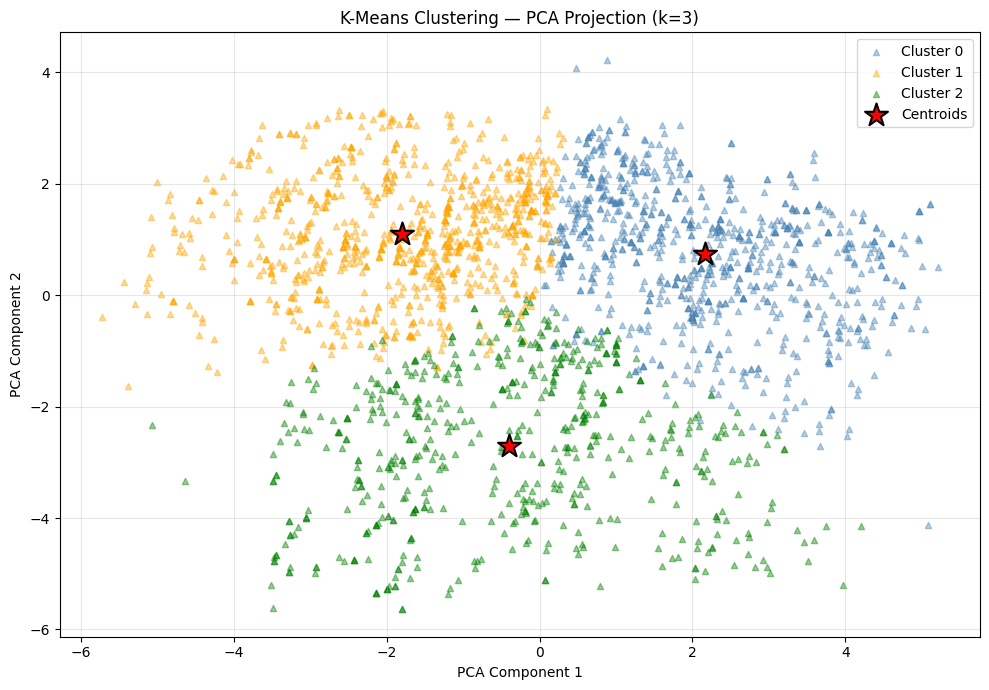

In [45]:
optimal_k = 3  # justified by elbow + silhouette
km_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42) # gives cluster labels (0, 1, 2) and centroids of clusters
cluster_labels = km_final.fit_predict(X_test_scaled) # finds cluster centers and assign every car to a cluster

# PCA reduction to 2D
pca = PCA(n_components=2, random_state=42) # compresses multi column data down to exactly 2D (X and Y)
X_pca = pca.fit_transform(X_test_scaled) # calculates the math to compress rows and outputs a new matrix X_pca containing only two columns
centroids_pca = pca.transform(km_final.cluster_centers_) # aligns centroids on new 2D grid

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'orange', 'green']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(optimal_k):
    mask = cluster_labels == i # isolates cars belonging to that specific cluster (0,1 or 2)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], marker = '^', alpha=0.4, s=20, label=cluster_names[i])

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='*', s=300, edgecolors='black',
            linewidth=1.5, label='Centroids', zorder=5)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering — PCA Projection (k=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations from Cluster Visualisation

The PCA scatter plot shows three reasonably separated clusters with 
centroids (red stars) well distributed in PCA space. Cluster 0 
(blue) and Cluster 1 (orange) show significant overlap in the 
middle region — consistent with boundary cases between Compact and 
Midsize vehicles observed in Phase 7. Cluster 2 (green) occupies 
the lower region of PCA space suggesting it captures a distinct 
feature combination likely corresponding to a specific performance 
or size category.

## 8.4 Cluster Profiling

This cell computes mean feature values per cluster and plots a 
grouped bar chart to characterise each cluster with a descriptive label.

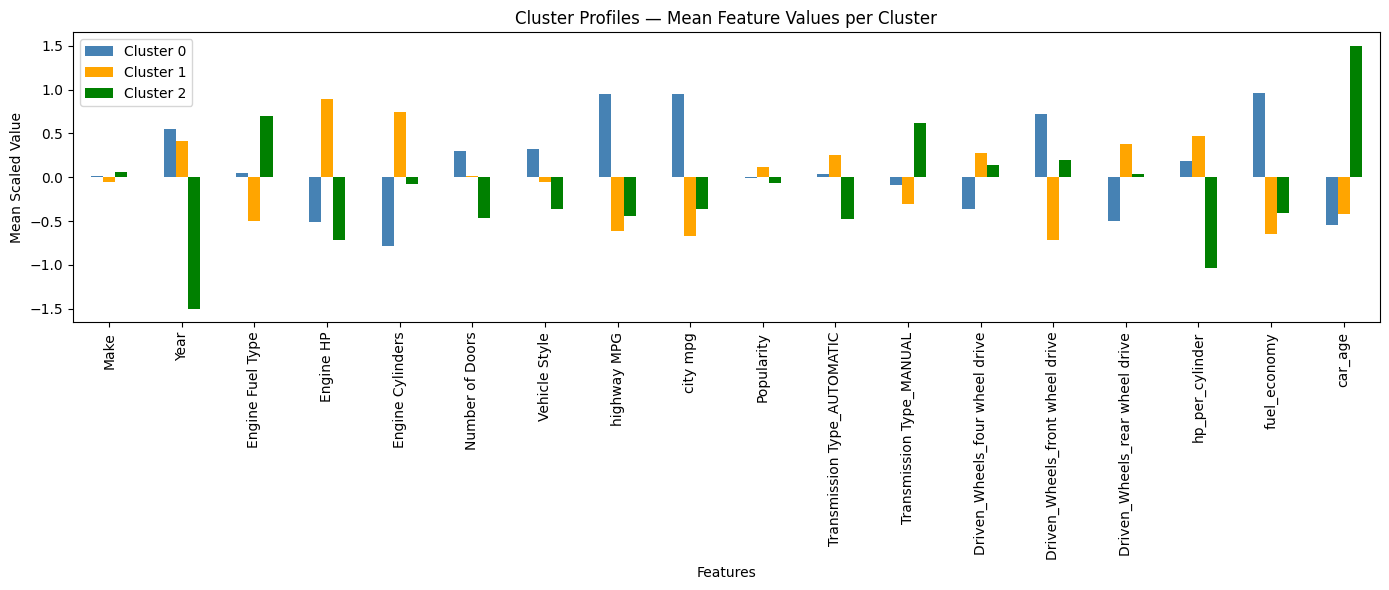


Cluster Mean Values (Top Features):
         Engine HP  Engine Cylinders  highway MPG  car_age
Cluster                                                   
0           -0.514            -0.785        0.948   -0.548
1            0.896             0.743       -0.619   -0.414
2           -0.716            -0.072       -0.438    1.504


In [46]:
X_test_df = pd.DataFrame(X_test_scaled.values, 
                          columns=X_test_scaled.columns)


X_test_df['Cluster'] = cluster_labels

# Mean of each original feature per cluster
cluster_means = X_test_df.groupby('Cluster').mean()

# Plot grouped bar chart
cluster_means.T.plot(kind='bar', figsize=(14, 6), 
                      color=['steelblue', 'orange', 'green'])
plt.title('Cluster Profiles — Mean Feature Values per Cluster')
plt.xlabel('Features')
plt.ylabel('Mean Scaled Value')
plt.xticks(rotation=90)
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.tight_layout()
plt.show()

print("\nCluster Mean Values (Top Features):")
print(cluster_means[['Engine HP', 'Engine Cylinders', 
                       'highway MPG', 'car_age']].round(3))

## Observations from Cluster Profiling

Based on mean scaled feature values per cluster the three clusters 
represent distinct automotive operating regimes:

| Cluster | Label | Key Characteristics |
|---|---|---|
| **Cluster 0** (Blue) | Recent Economy Vehicles | High Year (+0.95), High highway MPG (+0.95), High city mpg (+0.95), Low Engine HP (-0.3), Low Engine Cylinders (-0.65) — newer fuel-efficient economy cars |
| **Cluster 1** (Orange) | Older Performance Vehicles | High Engine HP (+0.9), High Engine Cylinders (+0.7), Low highway MPG (-0.5), Low city mpg (-0.5), High car_age (+0.95) — older powerful vehicles |
| **Cluster 2** (Green) | Old Low-Efficiency Vehicles | Very High car_age (+1.5), Very Low Year (-1.4), Low hp_per_cylinder (-1.05), Moderate Engine HP — very old cars with inefficient engines |

### Key Feature Observations

**Year and car_age** show the strongest separation between clusters:
- Cluster 0 → newest cars (Year high, car_age low)
- Cluster 1 → middle-aged cars
- Cluster 2 → oldest cars (Year very low, car_age very high = -1.4 to +1.5 swing)

**Engine HP and Engine Cylinders** clearly separate Cluster 1 from others:
- Cluster 1 has highest Engine HP (+0.9) and Engine Cylinders (+0.7)
- Cluster 0 has lowest Engine Cylinders (-0.65) — small efficient engines

**highway MPG and city mpg** show strong positive values for Cluster 0:
- Cluster 0 → most fuel efficient (+0.95 both) — confirms economy vehicle label
- Cluster 1 → least fuel efficient (-0.5 both) — confirms powerful vehicle label

**hp_per_cylinder** shows interesting pattern:
- Cluster 0 → high hp_per_cylinder (+0.65) — modern efficient engines
- Cluster 2 → very low hp_per_cylinder (-1.05) — old inefficient engines

### Cluster Descriptive Labels
- **Cluster 0** → *"Recent fuel-efficient economy vehicles"*
- **Cluster 1** → *"Older high-performance powerful vehicles"*  
- **Cluster 2** → *"Very old low-efficiency legacy vehicles"*

### Key Takeaway
The clusters are primarily separated by **vehicle age** (Year/car_age) 
and **engine characteristics** (HP, Cylinders, MPG) — the two most 
dominant feature groups in the dataset. This confirms that K-Means 
discovered meaningful automotive operating regimes based purely on 
engineering specifications without using any class labels.

## Observations from Cluster Profiling

## 8.5 Cluster-Target Cross Tabulation

This cell computes a cross tabulation of discovered cluster labels 
against known Vehicle Size classification target to assess alignment.

Cross Tabulation — Clusters vs Vehicle Size:
Vehicle Size    0    1    2
Cluster                    
0             438  353   54
1             207  308  370
2             272  189  128


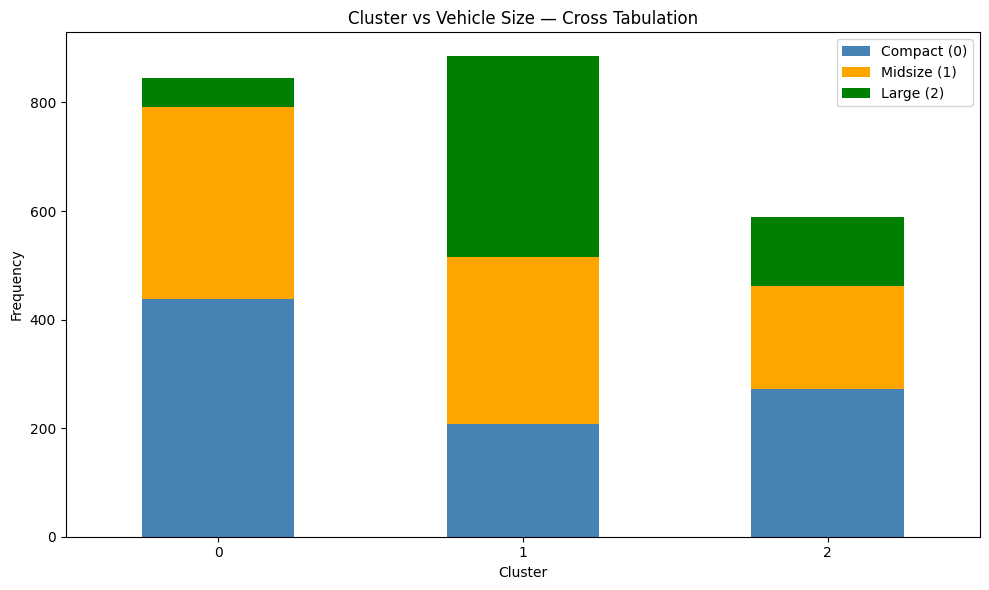

In [47]:
cross_tab = pd.crosstab(cluster_labels, yc_test, 
                         rownames=['Cluster'], 
                         colnames=['Vehicle Size'])
print("Cross Tabulation — Clusters vs Vehicle Size:")
print(cross_tab)

# Stacked bar chart
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6),
               color=['steelblue', 'orange', 'green'])

plt.title('Cluster vs Vehicle Size — Cross Tabulation')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.legend(['Compact (0)', 'Midsize (1)', 'Large (2)'])
plt.tight_layout()
plt.show()

## Observations from Cluster-Target Cross Tabulation

The stacked bar chart reveals that all three clusters contain a mix 
of Vehicle Size classes — clusters do not perfectly align with 
known labels. Each cluster is dominated by one class but contains 
significant proportions of others:

- **Cluster 0** → dominated by Compact (blue) — mostly economy vehicles
- **Cluster 1** → mixed Compact/Midsize/Large — middle-ground vehicles  
- **Cluster 2** → mixed distribution — boundary vehicles

The imperfect alignment is expected — K-Means discovers clusters 
based purely on feature similarity without using size labels. Where 
clusters and labels disagree these are boundary cases where vehicle 
specifications overlap between size categories — the same challenge 
observed in Phase 7 classification where Midsize and Large were most 
commonly confused.

If clusters aligned perfectly it would suggest size categories are 
completely determined by measurable specs alone — the partial 
alignment confirms size is strongly but not exclusively determined 
by engineering features.

## Save Additional Objects

This cell saves the additional objects required for dashboard.

In [48]:
import joblib
import os
import json

save_dir = r"H:\Uni Semesters\Semester 6\DS&A\Semester Project\dashboard\models"
os.makedirs(save_dir, exist_ok=True)

# Save K-Means model
joblib.dump(km_final, os.path.join(save_dir, 'kmeans_model.pkl'))
print("K-Means saved")

# Save PCA object
joblib.dump(pca, os.path.join(save_dir, 'pca_model.pkl'))
print("PCA saved")

# Save StandardScaler
joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
print("Scaler saved")

# Save feature column order (critical for prediction)
feature_cols = X_train_scaled.columns.tolist()
with open(os.path.join(save_dir, 'feature_columns.json'), 'w') as f:
    json.dump(feature_cols, f)
print("Feature columns saved")

print("\nAll objects saved successfully")
print(f"Location: {save_dir}")

K-Means saved
PCA saved
Scaler saved
Feature columns saved

All objects saved successfully
Location: H:\Uni Semesters\Semester 6\DS&A\Semester Project\dashboard\models


---
## End of Notebook
All 8 analytical phases completed. Phase 9 (Streamlit Dashboard) is implemented in `../dashboard/app.py`.